In [1]:
#%% Loading packages

# current env : retrieval
# now switching to orcestra-retrieval-env
import numpy as np

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import fsspec
from matplotlib import cm
from matplotlib.colors import Normalize 
from scipy.interpolate import interpn
import glob
from functools import partial
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/')
#import src
import src_comparison_halo_pamtra as chp
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
path_sim = "/work/mh0731/m301067/misc/"
ds_old=xr.open_dataset(path_sim + 'orcestra_1250m_0927-rerun4janina/orcestra_1250m_0927-rerun_atm_2d_ml_DOM01_20240927T000000Z.nc')

In [6]:
file='0922-rerun/orcestra_1250m_0922-rerun_3d_hpz12.zarr'
file='bc-land/orcestra_1250m_bc_land_hpz12.zarr'
path='/work/mh0492/m301067/orcestra/healpix/'
ds=xr.open_dataset(path+file, engine="zarr")#radiometer

In [10]:
ds

<xarray.Dataset> Size: 675MB
Dimensions:        (cell: 9371648, nv: 3)
Coordinates:
  * cell           (cell) int64 75MB 50331648 50331649 ... 201326590 201326591
    crs            float32 4B ...
Dimensions without coordinates: nv
Data variables:
    clat_bnds      (nv, cell) float32 112MB ...
    clon_bnds      (nv, cell) float32 112MB ...
    fract_glac     (cell) float32 37MB ...
    fract_lake     (cell) float32 37MB ...
    fract_land     (cell) float32 37MB ...
    fract_veg      (cell) float32 37MB ...
    glac           (cell) float32 37MB ...
    lake           (cell) float32 37MB ...
    land           (cell) float32 37MB ...
    notsea         (cell) float32 37MB ...
    sea            (cell) float32 37MB ...
    veg_ratio_max  (cell) float32 37MB ...

In [11]:
ds_old


<xarray.Dataset> Size: 409GB
Dimensions:      (time: 25, height: 56, bnds: 2, ncells: 12174205)
Coordinates:
  * time         (time) datetime64[ns] 200B 2024-09-27 ... 2024-09-29
  * height       (height) float64 448B 35.0 36.0 37.0 38.0 ... 88.0 89.0 90.0
Dimensions without coordinates: bnds, ncells
Data variables:
    height_bnds  (height, bnds) float64 896B ...
    qv           (time, height, ncells) float32 68GB ...
    qc           (time, height, ncells) float32 68GB ...
    qi           (time, height, ncells) float32 68GB ...
    qs           (time, height, ncells) float32 68GB ...
    qg           (time, height, ncells) float32 68GB ...
    qr           (time, height, ncells) float32 68GB ...
Attributes:
    CDI:                  Climate Data Interface version 2.4.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  42
    uuidOfHGrid:          d91eb16c-5cb5-11ef-bad0-d926b45399a4
    uuidOfVGrid:          fd43182e-8d6a-0492-0406-d10ddfc73a20
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               https://gitlab.dkrz.de/icon/icon-mpim.git@1fa5838fd...
    history:              /work/mh0492/m301067/orcestra/icon-mpim/build-lamor...
    references:           see MPIM/DWD publications
    comment:              Romain Fievet (m301067) on l50359 (Linux 4.18.0-513...

## 025 lon x 025 lat - Visualisation and saving of cells

In [5]:
# selection of cells by lon and lat?
#first plot cell/lon and cell/lat

#lat = np.rad2deg(grid2.clat.to_pandas())#[frac_land.sea.to_pandas()==1])
#lon=np.rad2deg(grid2.clon.to_pandas())#[frac_land.sea.to_pandas()==1])

#grid=grid[["clon","clat"]]
#grid.clon.plot()
grid,frac_land = chp.read_grid_and_cell_data()
lat = np.rad2deg(grid.clat.to_pandas())#[frac_land.sea.to_pandas()==1])
lon=np.rad2deg(grid.clon.to_pandas())#[frac_land.sea.to_pandas()==1])
s_lat = -2
w_lon = -62
e_lon= -16
n_lat=22
try:    
    n_lat
    s_lat,
    e_lon,
    w_lon
except:
    print("no complete definiton of lon and lat area")    
else:
    lat=lat[(lat <= n_lat )&(lat >= s_lat)]
    lon=lon[(lon <= e_lon)&(lon >= w_lon)]
lon=lon[(lon <= e_lon)]
common_idx=lon.index.intersection(lat.index)
idx_list=common_idx.to_list()
df_lon=pd.DataFrame(data={'lon':lon})
df_lat=pd.DataFrame(data={'lat':lat})
df=pd.concat([df_lon,df_lat],axis=1,join='inner')

In [36]:
lat

cell
136        -1.459009
137        -1.468113
138        -1.487547
139        -1.496652
140        -1.516086
              ...   
12173712   -1.997607
12173964   -1.946091
12173965   -1.955219
12173966   -1.974653
12173967   -1.983781
Name: clat, Length: 10512925, dtype: float64

In [24]:
lat

cell
0          -2.573164
1          -2.582289
2          -2.601715
3          -2.610841
4          -2.630267
              ...   
12174200   -3.727636
12174201   -3.747056
12174202   -3.756220
12174203   -3.775640
12174204   -3.784805
Name: clat, Length: 12174205, dtype: float64

In [6]:
df

,lon,lat
cell,,
511201,-61.999927,-1.122857
511202,-61.999449,-1.132074
511205,-61.999375,-1.151539
511206,-61.998897,-1.160756
511209,-61.998828,-1.180221
...,...,...
10640683,-16.004090,-1.935556
10640684,-16.004457,-1.945086
10640687,-16.004412,-1.964626


In [35]:
df

,lon,lat
cell,,
511201,-61.999927,-1.122857
511202,-61.999449,-1.132074
511205,-61.999375,-1.151539
511206,-61.998897,-1.160756
511209,-61.998828,-1.180221
...,...,...
10640683,-16.004090,-1.935556
10640684,-16.004457,-1.945086
10640687,-16.004412,-1.964626


In [2]:
def haversine_np(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    All args must be of equal length.    
    
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6378.137 * c
    return km
#ds=df.to_xarray()
#df[0:50]
xlon = np.arange(-61.75,-16,0.25)
ylat = np.arange(21.75,-2,-0.25)

xvlon, yvlat = np.meshgrid(xlon, ylat)

df_coarse = pd.DataFrame(data={'xlon':xvlon.flatten(),'xlat':yvlat.flatten(),'cell':np.zeros(len(yvlat.flatten()))})
df_coarse



,xlon,xlat,cell
0,-61.75,21.75,0.0
1,-61.50,21.75,0.0
2,-61.25,21.75,0.0
3,-61.00,21.75,0.0
4,-60.75,21.75,0.0
...,...,...,...
17380,-17.25,-1.75,0.0
17381,-17.00,-1.75,0.0
17382,-16.75,-1.75,0.0
17383,-16.50,-1.75,0.0


In [7]:
%%time
#cell=[]
i=0
for ilon, ilat in zip(df_coarse.xlon,df_coarse.xlat):
    df_km=haversine_np(df['lon'],df['lat'],ilon,ilat)
    df[df_km==df_km.min()]
    df_km=haversine_np(df['lon'],df['lat'],ilon,ilat)
    #cell.append(df[df_km==df_km.min()    ].index.values[0])
    df_coarse.loc[i,'cell']=df[df_km==df_km.min()    ].index.values[0]
    i+=1

CPU times: user 4h 12min 4s, sys: 3h 5min 2s, total: 7h 17min 6s
Wall time: 7h 19min 19s


In [3]:
#df_coarse.to_csv('cellvalues_for_025lonx025lat_new_sims.csv')
df_coarse= pd.read_csv('cellvalues_for_025lonx025lat_new_sims.csv')
df_coarse

,Unnamed: 0,xlon,xlat,cell
0,0,-61.75,21.75,969887.0
1,1,-61.50,21.75,1018595.0
2,2,-61.25,21.75,1067322.0
3,3,-61.00,21.75,1119818.0
4,4,-60.75,21.75,1168574.0
...,...,...,...,...
17380,17380,-17.25,-1.75,10365503.0
17381,17381,-17.00,-1.75,10418309.0
17382,17382,-16.75,-1.75,10474860.0
17383,17383,-16.50,-1.75,10531402.0


In [8]:
#df_coarse
#df_coarse.to_csv('cellvalues_for_025lonx025lat.csv')
idx=df_coarse['cell'] #oder to list? to int?
grid,frac_land = chp.read_grid_and_cell_data()
#idx_sea= idx[idx['cell']'==[frac_sea
lat = np.rad2deg(grid.clat.to_pandas())#[frac_land.sea.to_pandas()==1])
lon=np.rad2deg(grid.clon.to_pandas())#[frac_land.sea.to_pandas()==1])
#frac_sea=np.rad2deg(frac_land.sea.to_pandas()[frac_land.sea.to_pandas()==1])
frac_sea=np.around(frac_land.land.to_pandas())#[frac_land.fract_land.to_pandas()==1])
frac_sea=np.around(frac_land.sea.to_pandas())
#idx_sea.shape
frac_sea=frac_sea[frac_sea==1]
idx_sea=np.intersect1d(np.array(frac_sea.reset_index()['cell']),np.array(idx))
#frac_sea[6000:6100]
#idx
idx_sea.shape


(15651,)

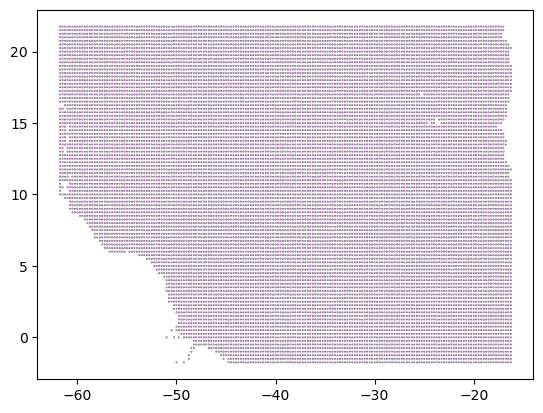

In [9]:
plt.scatter(lon[idx_sea],lat[idx_sea],marker=".",alpha=1,s=0.3,c=frac_sea[idx_sea])

In [17]:
df_coarse['cell']
cell_selection=idx_sea.astype(np.int64)

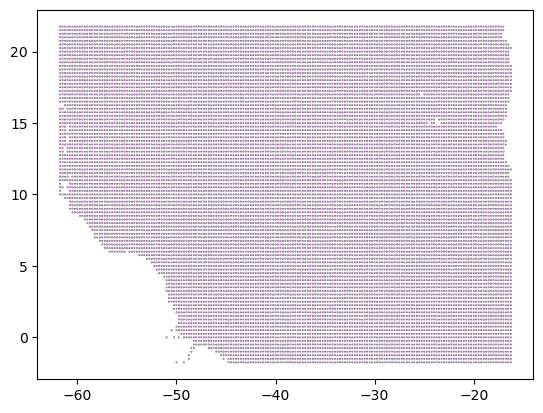

In [75]:
#df_coarse= pd.read_csv('cellvalues_for_025lonx025lat.csv')
#df_coarse
#c=np.array(cell)
#for i in range(len(np.array(c))):
#    df_coarse.loc[i,'cell']=np.array(c[i])
#grid,frac_land = chp.read_grid_and_cell_data()
#lat = np.rad2deg(grid.clat.to_pandas())#[frac_land.sea.to_pandas()==1])
#lon=np.rad2deg(grid.clon.to_pandas())#[frac_land.sea.to_pandas()==1])
#idx = df_coarse['cell'].astype('int')#[frac_land.sea.to_pandas()==1]
plt.scatter(lon[idx_sea],lat[idx_sea],marker=".",alpha=1,s=0.3,c=frac_sea[idx_sea])
#df_coarse#[9709:9711]
#plt.scatter(df_coarse['xlon'],df_coarse['xlat'],marker=".",alpha=1,s=0.3,c=df_coarse['cell'])
#lon[idx_remap]
#plt.scatter(lon[idx],lat[idx],marker=".",alpha=1,s=0.3,c=frac_sea[idx])


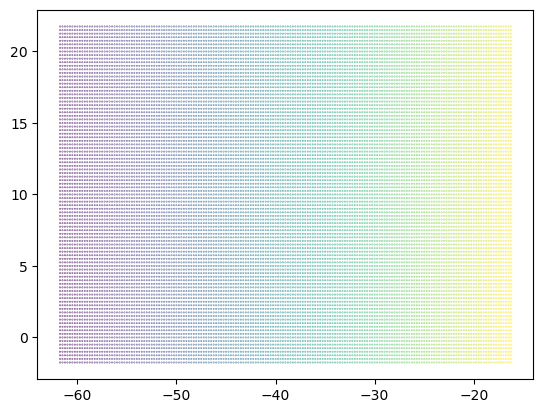

In [4]:
#np.save('cells_025x025_sea.npy',idx_sea)
#idx_sea=np.load('cells_025x025_sea.npy')
plt.scatter(df_coarse['xlon'],df_coarse['xlat'],marker=".",alpha=1,s=0.3,c=df_coarse['cell'])
#plt.scatter(lon[idx_sea],lat[idx_sea],marker="o",alpha=1,s=0.3)#,c=frac_sea[idx_sea])

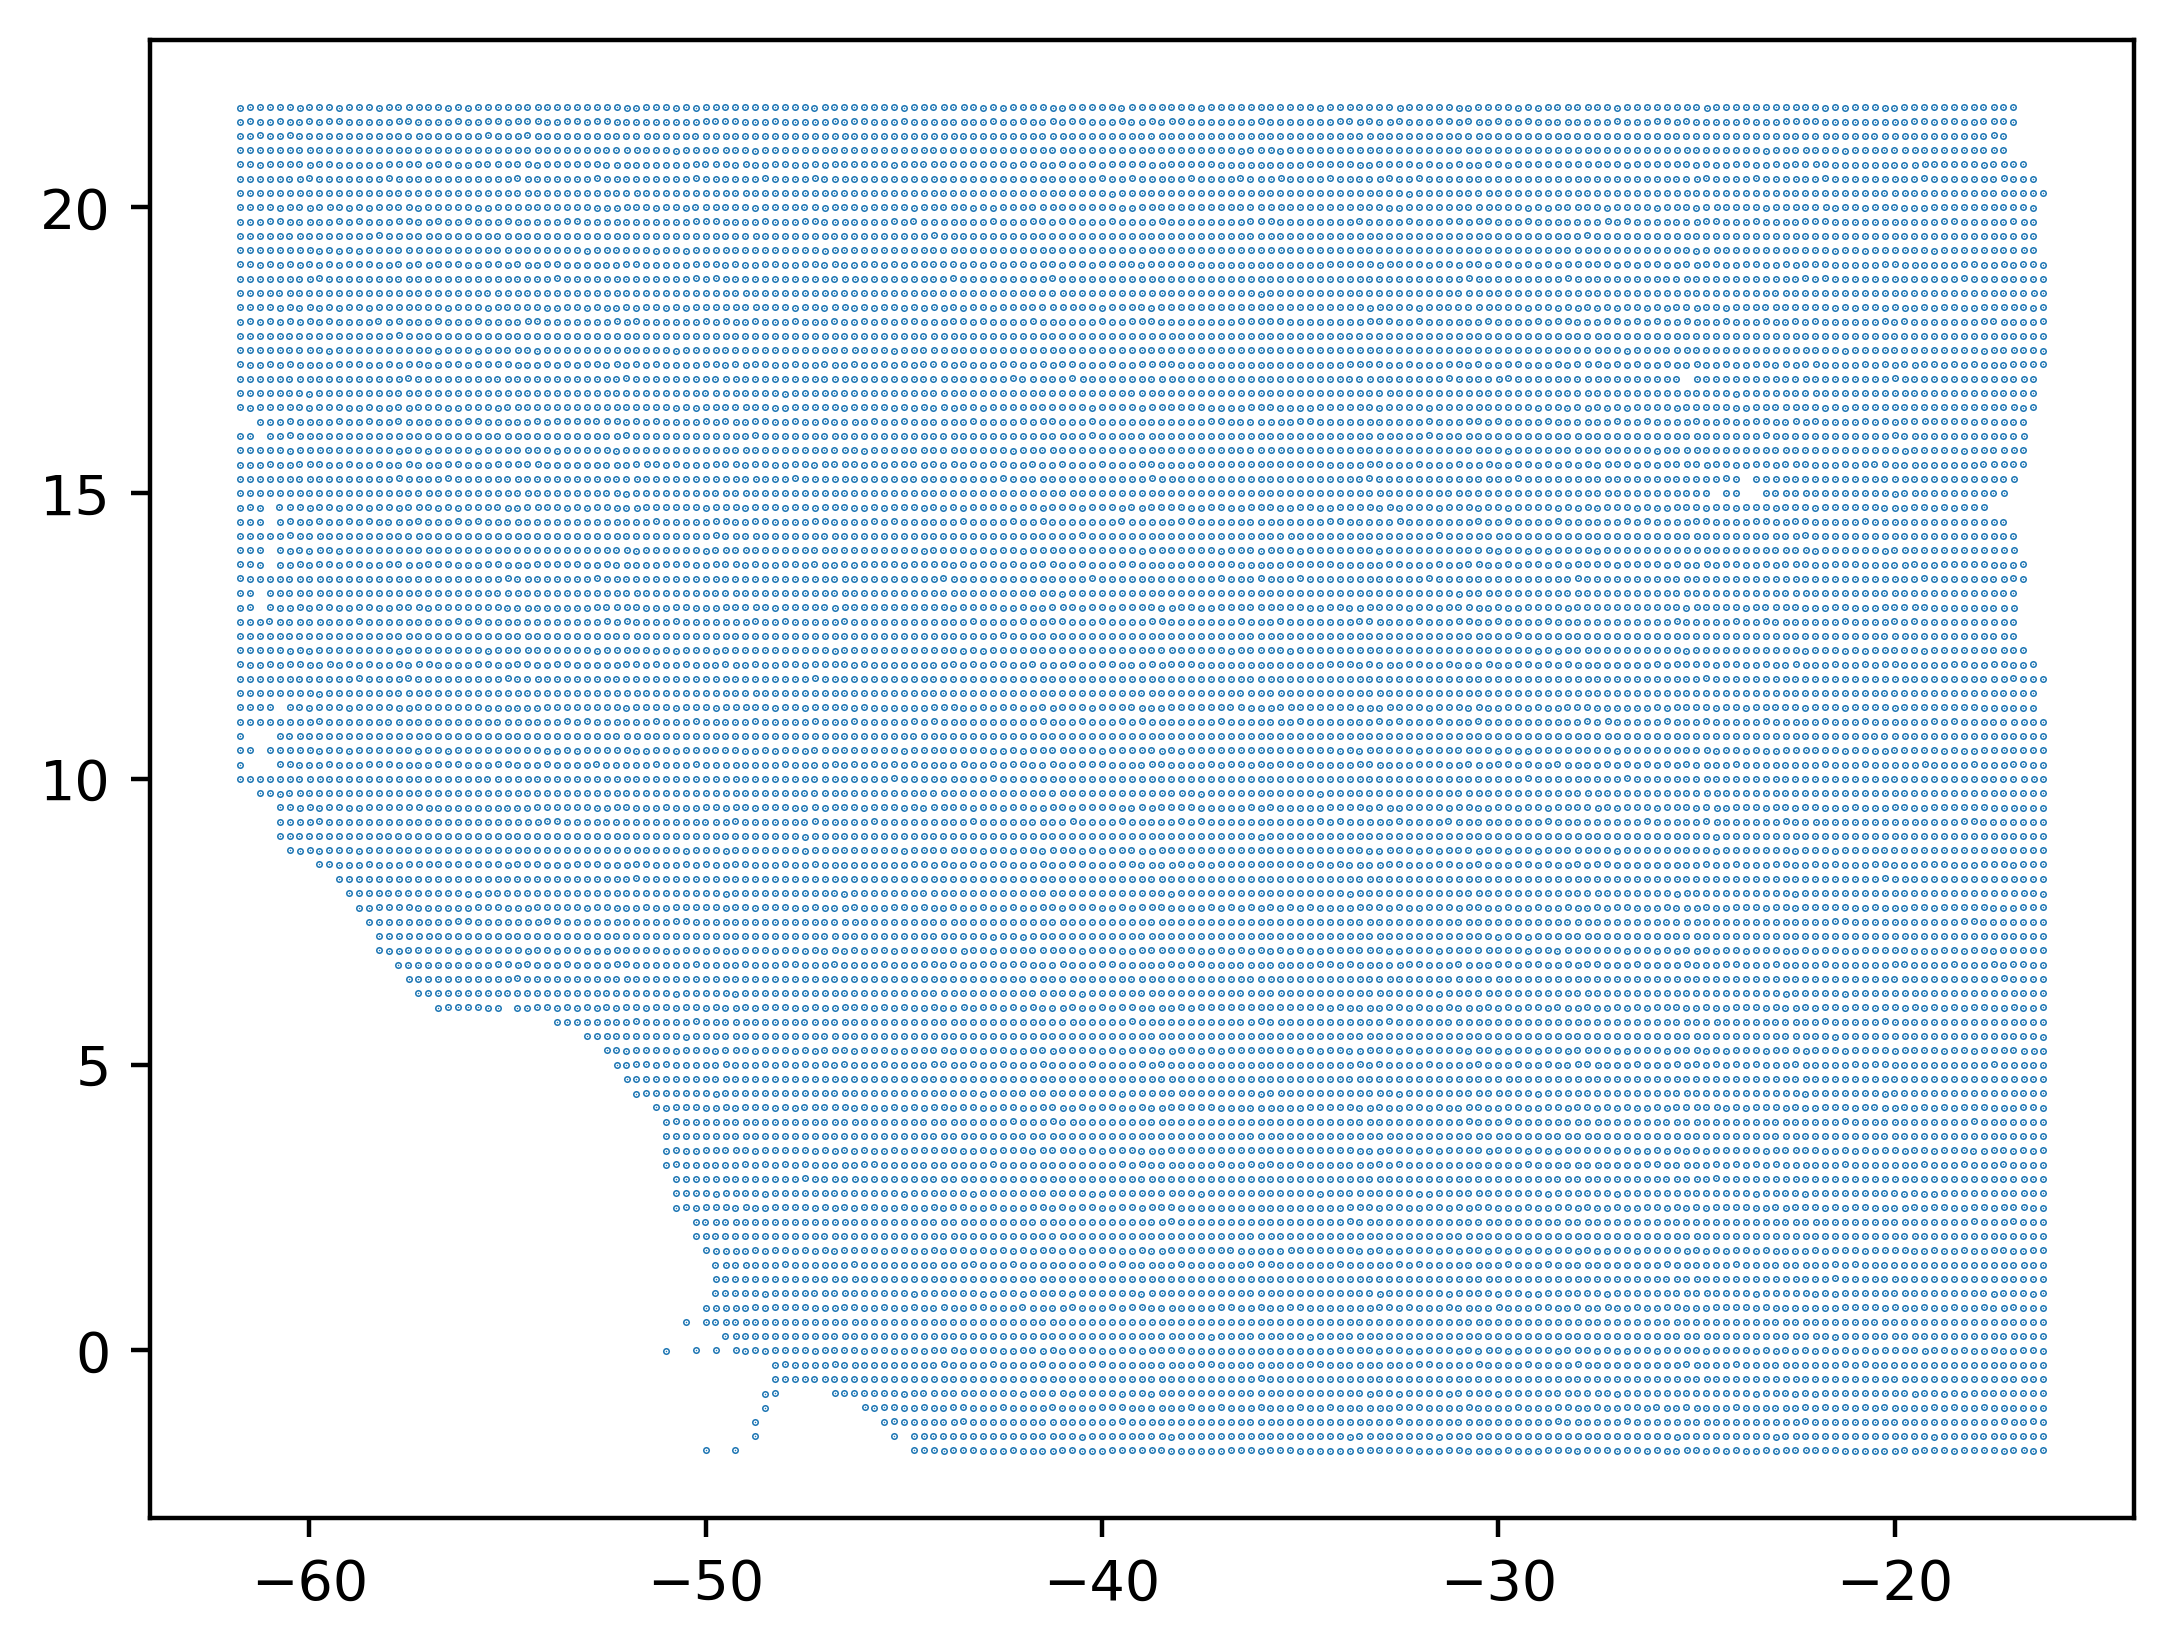

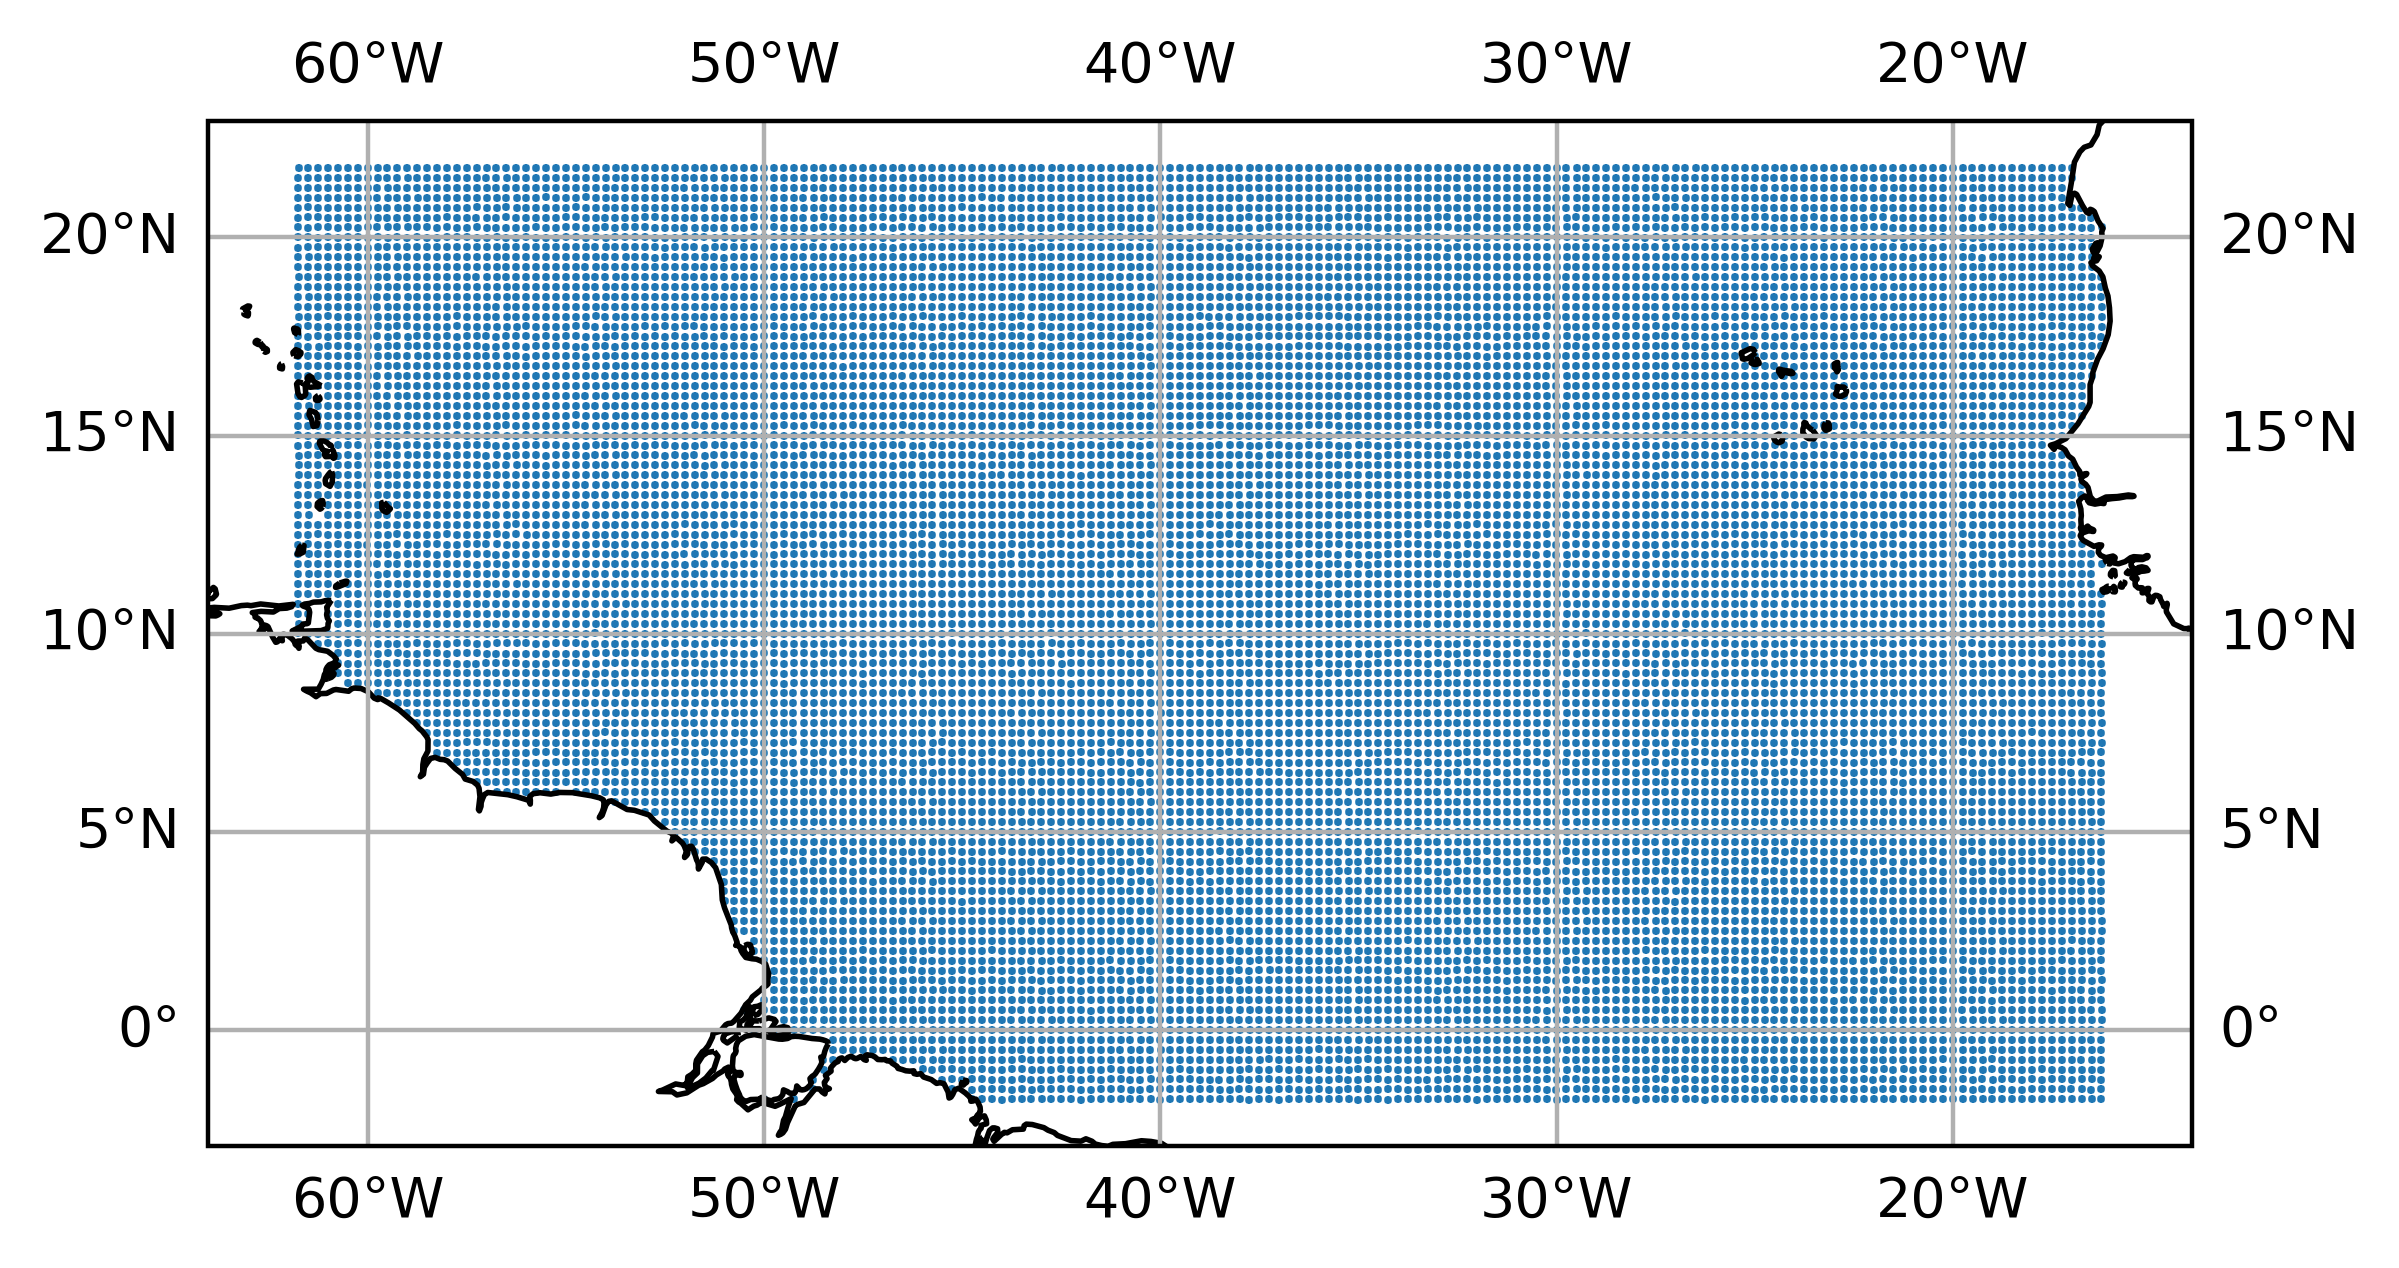

In [12]:
plt.rcParams['figure.dpi'] = 400
df_coarse= pd.read_csv('cellvalues_for_025lonx025lat.csv')
df_coarse
#c=np.array(cell)
#for i in range(len(np.array(c))):
#    df_coarse.loc[i,'cell']=np.array(c[i])
grid,frac_land = chp.read_grid_and_cell_data()
lat = np.rad2deg(grid.clat.to_pandas())#[frac_land.sea.to_pandas()==1])
lon=np.rad2deg(grid.clon.to_pandas())#[frac_land.sea.to_pandas()==1])
idx = df_coarse['cell'].astype('int')#[frac_land.sea.to_pandas()==1]
plt.scatter(lon[idx_sea],lat[idx_sea],marker=".",alpha=1,s=0.3)#,c=frac_sea[idx_sea])
#df_coarse#[9709:9711]
#plt.scatter(df_coarse['xlon'],df_coarse['xlat'],marker=".",alpha=1,s=0.3,c=df_coarse['cell'])
#lon[idx_remap]
#plt.scatter(lon[idx],lat[idx],marker=".",alpha=1,s=0.3,c=frac_sea[idx])
plt.show()
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(draw_labels=True)

sc = ax.scatter(lon[idx_sea],lat[idx_sea], s=0.1,marker=',', transform=ccrs.PlateCarree())
#plt.savefig('/home/u/u301032/orcestra/plots/map_subselection.jpg', dpi=400)

## Visualisation of first PAMTRA run, saving of cells

In [ ]:

# First Pamtra simulations: every 1000th icon cell, every 4 hours

#%%
# Choose Parameters #TODO In ein großes Dictionairy?
DATE= "0829" #"0927" #"0824" #
#NAME UNDER WHICH TO SAFE RUNS
output_name = "all_area_v1"
#Extend of Simulation area:
s_lat = -2
w_lon = -62
e_lon= -16
n_lat=22
flight_levels =[11400.0,11900.0,12650.0,13000.0,13250.0,13600.0,13900.0,14450.0,13900.0,15000.0	]
division_factor =1000 #1000 leads to ~ 6000 n_spatial

#%% reading file paths

if DATE == "0829":
    appendix = "-high3Drate"
else:
    appendix = "-rerun"

path_sim = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/"
path = path_sim + f"orcestra_1250m_{DATE+appendix}/"
height_file = path_sim + f"orcestra_1250m_0829-high3Drate/orcestra_1250m_0829-high3Drate_atm_vgrid_ml.nc"

meshdir = "/work/mh0492/m301067/orcestra/auxiliary-files/grids/"
meshname = "ORCESTRA_1250m_DOM01"
frac_land_file= path + "bc_land_frac.nc"


#%%
# reading files
grid = xr.open_dataset(meshdir+meshname+".nc")

frac_land= xr.open_dataset(frac_land_file)



# %%%
#timestamps for DATE == "0824"
# selection of time stamps: 00,04,08,12,16,20, 24, 28, 32, 36 h
# selection of time = 36:00h

#Für Colocation : von 8 bis 20:00h
day = DATE[2:5]
month = DATE[0:2]
if DATE == "0829":
    t_periods = 4
else:
    t_periods = 5 #from 10
t_steps =xr.date_range("2024-"+month+"-"+day+" 12:00:00",periods=t_periods,freq="4h")




#%% Index, spatial, TODO: Auslagern? da auch von pamtra comparison genutzt

lat = np.rad2deg(grid.clat.to_pandas()[frac_land.sea.to_pandas()==1])

lon=np.rad2deg(grid.clon.to_pandas()[frac_land.sea.to_pandas()==1])

try:    
    n_lat
    s_lat,
    e_lon,
    w_lon
except:
    print("no complete definiton of lon and lat area")    
else:
    #dif_lat = n_lat -s_lat
    #dif_lon = e_lon -w_lon
    #m= dif_lat/dif_lon
    #t = s_lat-m*s_lon
    ####
    lat=lat[(lat <= n_lat )&(lat >= s_lat)]
    lon=lon[(lon <= e_lon)&(lon >= w_lon)]
    
    #idx_subsample=random.sample(sorted(common_idx.to_numpy()),8000)
lon=lon[(lon <= e_lon)]
common_idx=lon.index.intersection(lat.index)
idx_list=common_idx.to_list()
#Reducing data size by factor 1000
common_idx=idx_list[0::division_factor]

In [10]:

np.save('cells_all_area_1000th_cell.npy',np.array(common_idx))
#t_steps

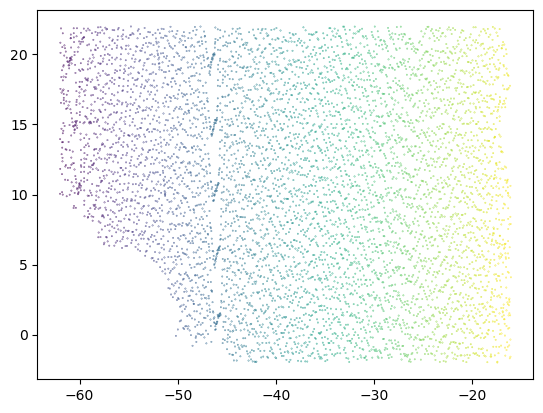

In [62]:

ds_alldays= xr.open_mfdataset(twodim_files,preprocess=partial_func)#,chunks="auto", parallel=True)
ds_alldays,common_idx,lon,lat=cut_data_to_area_of_interest(ds_alldays,division_factor=1000)
#common_idx


#common_idx=idx_list[0::1000]
plt.scatter(lon[common_idx],lat[common_idx],marker=".",alpha=1,s=0.3,c=common_idx)
#len(common_idx)
#grid,frac_land = read_grid_and_cell_data()

#grid,frac_land = read_grid_and_cell_data()
#lat = np.rad2deg(grid.clat.to_pandas()[frac_land.sea.to_pandas()==1])
#lon=np.rad2deg(grid.clon.to_pandas()[frac_land.sea.to_pandas()==1])
#idx_list=cells.to_list()
  #Reducing data size by factor 1000
#common_idx=idx_list[0::1000]
#c=common_idx
#cells=lon.index.intersection(lat.index)
#plt.scatter(lon[c],lat[c],marker=".",alpha=0.1,s=0.3,c=c)

# Histograms of Condensate Loads

### Histogram of all Datapoints in selected area

#### Reading in all days

In [2]:
# open hydfiles
# Deletion of old runs
# now using only reruns
#Read in all 2D fields.
case= 'new'#"rerun" # "old"
path_sim = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/"
twodim_files  = path_sim + "orcestra_1250m_[0-9][0-9][0-9][0-9]-rerun/orcestra_1250m_*_atm_2d_ml_DOM01_2024*T000000Z.nc" #"rerun"
path='/work/mh0492/m301067/orcestra/healpix/'
files = path + '0*-rerun/*2d_hpz12.zarr'
#twodim_files  = path_sim + "orcestra_1250m_[0-9][0-9][0-9][0-9]/orcestra_1250m_*_atm_2d_ml_DOM01_2024*T000000Z.nc" #old
variables = [
    'qv', #water vapor path
    'qi', #cloud ice path
    'qc', #cloud liquid water path
    'qr', #rain path
    'qs', #snow path
    'qg' #graupel path
  ]
# Opening Multifile Dataset
# Limiting simulation data from 24h - 48 h
def _preprocess(x, start_time="24h"):#, end_time="48h" ):
  # selecting variables of interest
  variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
  x=x[variables]

  # selecting time
  #start=x.time[0].values+pd.Timedelta(start_time)
  #stop=x.time[0].values +pd.Timedelta(end_time) #last time step
  #stop=x.time[-1].values #last time step
  #t_steps =xr.date_range(start,stop,freq="1h")
  #print(start)
  return x#.sel(time=t_steps)


#ds_alldays=xr.concat([xr.open_dataset(i,preprocess=partial_func,engine ="zarr")for i in twodim_files],dim="time")

twodim_files_list =glob.glob(twodim_files)
#ds_alldays=xr.concat([_preprocess(xr.open_dataset(i))for i in twodim_files_list],dim="time")
if case== "rerun":
    partial_func = partial(_preprocess,start_time="0h") #, end_time="48h")
    ds_alldays= xr.open_mfdataset(twodim_files,preprocess=partial_func,chunks="auto", parallel=True)#, chunks={"ncells": -1})#
if case== "old":    
    partial_func = partial(_preprocess,start_time="24h") #, end_time="48h")
    ds_alldays= xr.open_mfdataset(twodim_files,preprocess=partial_func,chunks="auto", parallel=True)#, chunks={"ncells": -1})#
if case== "new":
    partial_func = partial(_preprocess,start_time="24h") 
    ds_alldays= xr.open_mfdataset(files,preprocess=partial_func,chunks="auto", parallel=True)#, chunks={"ncells": -1})#
    #ds_alldays=ds_alldays[variables]

#ds,common_idx,lon,lat= chp.cut_data_to_area_of_interest(ds_alldays,division_factor=1)

#try and test if time steps are evenly distributed
#yes, every 2h
# try and test bin sizes

### Reading  old, saved histograms. Not feasible

In [29]:
ds_alldays

<xarray.Dataset> Size: 9TB
Dimensions:  (time: 7395, cell: 9371648)
Coordinates:
  * cell     (cell) int64 75MB 50331648 50331649 ... 201326590 201326591
    crs      float32 4B nan
  * time     (time) datetime64[ns] 59kB 2024-08-10 ... 2024-09-30
Data variables: (12/32)
    cllvi    (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    clt      (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    evspsbl  (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    hfls     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    hfss     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    hus2m    (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    ...       ...
    tas      (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    tauu     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    tauv     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    ts       (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    uas      (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    vas      (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>

In [19]:
variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
ds=ds_alldays[variables]
ds

<xarray.Dataset> Size: 2TB
Dimensions:  (time: 7395, cell: 9371648)
Coordinates:
  * cell     (cell) int64 75MB 50331648 50331649 ... 201326590 201326591
    crs      float32 4B nan
  * time     (time) datetime64[ns] 59kB 2024-08-10 ... 2024-09-30
Data variables:
    prw      (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qivi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    cllvi    (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qrvi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qsvi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qgvi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>

In [28]:
grid

<xarray.Dataset> Size: 10GB
Dimensions:                         (cell: 12174205, nv: 3, vertex: 6092192,
                                     edge: 18266396, no: 4, nc: 2, ne: 6,
                                     max_chdom: 1, cell_grf: 14, edge_grf: 24,
                                     vert_grf: 13)
Coordinates:
    clon                            (cell) float64 97MB dask.array<chunksize=(12174205,), meta=np.ndarray>
    clat                            (cell) float64 97MB dask.array<chunksize=(12174205,), meta=np.ndarray>
    vlon                            (vertex) float64 49MB dask.array<chunksize=(6092192,), meta=np.ndarray>
    vlat                            (vertex) float64 49MB dask.array<chunksize=(6092192,), meta=np.ndarray>
    elon                            (edge) float64 146MB dask.array<chunksize=(16777216,), meta=np.ndarray>
    elat                            (edge) float64 146MB dask.array<chunksize=(16777216,), meta=np.ndarray>
Dimensions without coordinates: cell, nv, vertex, edge, no, nc, ne, max_chdom,
                                cell_grf, edge_grf, vert_grf
Data variables: (12/79)
    clon_vertices                   (cell, nv) float64 292MB dask.array<chunksize=(8388606, 2), meta=np.ndarray>
    clat_vertices                   (cell, nv) float64 292MB dask.array<chunksize=(8388606, 2), meta=np.ndarray>
    elon_vertices                   (edge, no) float64 585MB dask.array<chunksize=(16777214, 1), meta=np.ndarray>
    elat_vertices                   (edge, no) float64 585MB dask.array<chunksize=(16777214, 1), meta=np.ndarray>
    cell_area                       (cell) float64 97MB dask.array<chunksize=(12174205,), meta=np.ndarray>
    dual_area                       (vertex) float64 49MB dask.array<chunksize=(6092192,), meta=np.ndarray>
    ...                              ...
    edge_dual_normal_cartesian_x    (edge) float64 146MB dask.array<chunksize=(16777216,), meta=np.ndarray>
    edge_dual_normal_cartesian_y    (edge) float64 146MB dask.array<chunksize=(16777216,), meta=np.ndarray>
    edge_dual_normal_cartesian_z    (edge) float64 146MB dask.array<chunksize=(16777216,), meta=np.ndarray>
    cell_circumcenter_cartesian_x   (cell) float64 97MB dask.array<chunksize=(12174205,), meta=np.ndarray>
    cell_circumcenter_cartesian_y   (cell) float64 97MB dask.array<chunksize=(12174205,), meta=np.ndarray>
    cell_circumcenter_cartesian_z   (cell) float64 97MB dask.array<chunksize=(12174205,), meta=np.ndarray>
Attributes: (12/34)
    title:                    ICON grid description
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    source:                   https://gitlab.dkrz.de/mpim-sw/grid-generator.git
    revision:                 ea19a5a87b7d344a2e4ca7adce6da6d6b8e2307b
    history:                  /work/mh0492/m301067/orcestra/grid-generator/bu...
    date:                     20240817 at 182917
    ...                       ...
    mean_cell_area:           1542897.48950126
    mean_dual_cell_area:      3083320.205395578
    domain_length:            40031612.44147649
    domain_height:            40031612.44147649
    sphere_radius:            6371229.0
    domain_cartesian_center:  [0. 0. 0.]

In [85]:
cells=ds_alldays.cell.values

In [87]:
list(set(cells)&set(cell_selection))

[]

In [88]:
cells

array([ 50331648,  50331649,  50331650, ..., 201326589, 201326590,
       201326591])

In [89]:
cell_selection

array([  679623,   687030,   687065, ..., 10584085, 10584118, 10584152])

In [81]:
cell_selection = np.load('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/cells_025x025_sea.npy') #old
#ds#.sel(cell=cell_selection)
#print(cell_selection,ds.cell,grid)

In [14]:
land=xr.open_mfdataset('/work/mh0492/m301067/orcestra/healpix/bc-land/orcestra_1250m_bc_land_hpz12.zarr',chunks="auto", parallel=True)
vgrid=xr.open_mfdataset('/work/mh0492/m301067/orcestra/healpix/vgrid/orcestra_1250m_vgrid_hpz12.zarr',chunks="auto", parallel=True)
print(land,vgrid)

<xarray.Dataset> Size: 675MB
Dimensions:        (cell: 9371648, nv: 3)
Coordinates:
  * cell           (cell) int64 75MB 50331648 50331649 ... 201326590 201326591
    crs            float32 4B ...
Dimensions without coordinates: nv
Data variables:
    clat_bnds      (nv, cell) float32 112MB dask.array<chunksize=(3, 9371648), meta=np.ndarray>
    clon_bnds      (nv, cell) float32 112MB dask.array<chunksize=(3, 9371648), meta=np.ndarray>
    fract_glac     (cell) float32 37MB dask.array<chunksize=(9371648,), meta=np.ndarray>
    fract_lake     (cell) float32 37MB dask.array<chunksize=(9371648,), meta=np.ndarray>
    fract_land     (cell) float32 37MB dask.array<chunksize=(9371648,), meta=np.ndarray>
    fract_veg      (cell) float32 37MB dask.array<chunksize=(9371648,), meta=np.ndarray>
    glac           (cell) float32 37MB dask.array<chunksize=(9371648,), meta=np.ndarray>
    lake           (cell) float32 37MB dask.array<chunksize=(9371648,), meta=np.ndarray>
    land           (cell) 

In [38]:
xr.open_dataset('/work/mh0492/m301067/orcestra/auxiliary-files/weights/weights_ORCESTRA_1250m_DOM01_HPZ12.nc')
xr.open_dataset('/work/mh0492/m301067/orcestra/auxiliary-files/weights/weights_ORCESTRA_1250m_DOM01_ZoomLvl3.nc')


<xarray.Dataset> Size: 345MB
Dimensions:  (tgt_idx: 9331200, tri: 3)
Dimensions without coordinates: tgt_idx, tri
Data variables:
    src_idx  (tgt_idx, tri) int32 112MB ...
    weights  (tgt_idx, tri) float64 224MB ...
    valid    (tgt_idx) bool 9MB ...

In [16]:
land.sea

<xarray.DataArray 'sea' (cell: 9371648)> Size: 37MB
dask.array<open_dataset-sea, shape=(9371648,), dtype=float32, chunksize=(9371648,), chunktype=numpy.ndarray>
Coordinates:
  * cell     (cell) int64 75MB 50331648 50331649 ... 201326590 201326591
    crs      float32 4B ...
Attributes:
    CDI_grid_type:                unstructured
    data_set:                     GLOBE
    institution:                  DWD
    long_name:                    Fraction of ocean
    number_of_grid_in_reference:  1
    standard_name:                land_area_fraction

In [12]:

#datadir = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/orcestra_1250m_"+mmdd+"/"
weightsdir = "/work/mh0492/m301067/orcestra/auxiliary-files/weights/"
#datafile = "orcestra_1250m_"+mmdd+"_atm_2d_ml_DOM01_2024"+mmdd+ "T000000Z.nc"
meshdir = "/work/mh0492/m301067/orcestra/auxiliary-files/grids/"
meshname = "ORCESTRA_1250m_DOM01"
onefile= "/work/mh0492/m301067/orcestra/healpix/0927-rerun/orcestra_1250m_0927-rerun_2d_hpz12.zarr"
#ds =  xr.open_dataset(onefile, chunks={"cell": -1}) 
ds = xr.open_mfdataset(files,chunks={"cell": -1})
grid = xr.open_dataset(meshdir+meshname+".nc")
import os
import easygems.remap as egr
os.environ['TEXMFHOME'] = '/home/m/m301067/texmf'
os.environ['PATH'] = '/sw/spack-levante/texlive-live2021-l5o6sw/bin/x86_64-linux:' + os.environ['PATH']
# Choose the resolution
ires = 3 #1:HD, 2:2K, 3:4k(~1.25km resolution)

# Update the figure's size according to target resolution
nx, ny = 1440 * ires, 720 * ires
dpi = 150*ires
#plt.rcParams['figure.dpi'] = 150*ires #450: 4K, 300: 2K, 150: HD to stay coherent

lon, lat = np.meshgrid(
    np.linspace(grid.clon.min().values, grid.clon.max().values, nx), 
    np.linspace(grid.clat.min().values, grid.clat.max().values, ny)
)

# Compute (load) remapping weights
weightsname = "weights_"+meshname+"HPZ12.nc"#"_ZoomLvl"+str(ires)
#if os.path.exists(weightsdir+weightsname+".nc"):
#    print("Reading weights")
#    weights = xr.open_dataset(weightsdir+weightsname+".nc")
#else:
#    print("Calculating weights")
#    weights = egr.compute_weights_delaunay((grid.clon, grid.clat), (lon.ravel(), lat.ravel()))
#    weights.to_netcdf(weightsdir+weightsname+".nc", mode="w")
#weights=xr.open_dataset('/work/mh0492/m301067/orcestra/auxiliary-files/weights/weights_ORCESTRA_1250m_DOM01_ZoomLvl3.nc')
weights=xr.open_dataset('/work/mh0492/m301067/orcestra/auxiliary-files/weights/weights_ORCESTRA_1250m_DOM01_HPZ12.nc')
# Apply remapping function only to the variables we need
ds_remap = xr.apply_ufunc(
    egr.apply_weights,
    ds,
    kwargs=weights,
    input_core_dims=[["cell"]],
    output_core_dims=[["xy"]],
    output_dtypes=["f4"],
    vectorize=True,
    dask="parallelized",
    dask_gufunc_kwargs={
        "output_sizes": {"xy": lon.size},
    },
)

# Assign the MultiIndex to the 'xy' dimension
ds_remap = ds_remap.assign_coords(
    xy=pd.MultiIndex.from_product(
        (np.degrees(lat[:, 0]), np.degrees(lon[0, :])), 
        names=("lat", "lon"),
    )
).unstack("xy")


/tmp/ipykernel_1148221/3667471075.py:54: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'xy' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  ds_remap = ds_remap.assign_coords(


In [17]:
ds_alldays.where(land.sea==1,other=np.nan)

<xarray.Dataset> Size: 2TB
Dimensions:  (time: 7395, cell: 9371648)
Coordinates:
  * cell     (cell) int64 75MB 50331648 50331649 ... 201326590 201326591
    crs      float32 4B nan
  * time     (time) datetime64[ns] 59kB 2024-08-10 ... 2024-09-30
Data variables:
    prw      (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qivi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    cllvi    (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qrvi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qsvi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>
    qgvi     (time, cell) float32 277GB dask.array<chunksize=(54, 589824), meta=np.ndarray>

In [72]:
#ds_remap
bc_land=xr.open_dataset('/work/mh0492/m301067/orcestra/healpix/bc-land/orcestra_1250m_bc_land_hpz12.zarr')

bc_land== xr.apply_ufunc(
    egr.apply_weights,
    ds,
    kwargs=weights,
    input_core_dims=[["cell"]],
    output_core_dims=[["xy"]],
    output_dtypes=["f4"],
    vectorize=True,
    dask="parallelized",
    dask_gufunc_kwargs={
        "output_sizes": {"xy": lon.size},
    },
)

# Assign the MultiIndex to the 'xy' dimension
bc_land = bc_land.assign_coords(
    xy=pd.MultiIndex.from_product(
        (np.degrees(lat[:, 0]), np.degrees(lon[0, :])), 
        names=("lat", "lon"),
    )
).unstack("xy")


/tmp/ipykernel_2741590/3674854554.py:19: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'xy' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  bc_land = bc_land.assign_coords(


In [75]:
ds_sea=ds_remap.where(bc_land.sea==1,other=np.nan)

IndexError: index 10527420 is out of bounds for axis 0 with size 9371648

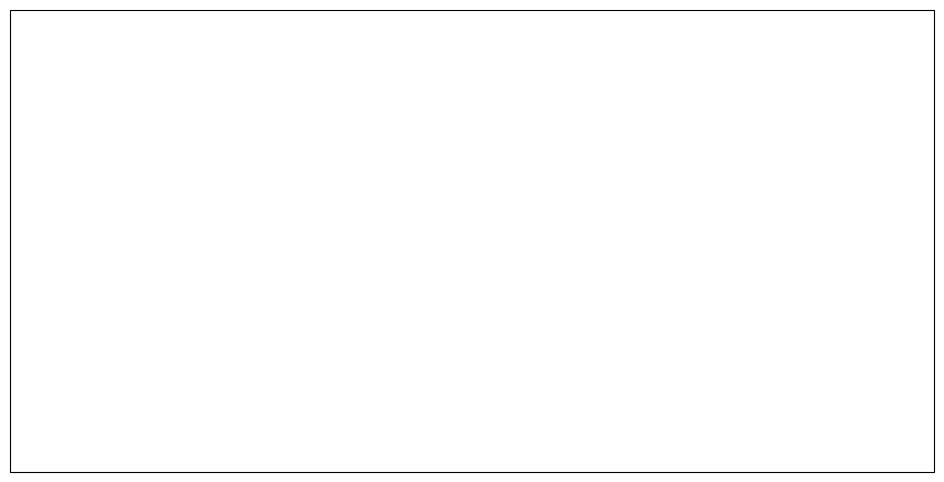

In [80]:
cllvi = ds_sea.cllvi.isel(time=1)

fig, ax = plt.subplots(figsize=(13, 6), subplot_kw={'projection': ccrs.PlateCarree()})
cllvi.plot( ax=ax, add_colorbar=False,transform=ccrs.PlateCarree())


In [ ]:
for v in variables:
    re_runs_hr=ds_bins_hr[v].sel(time=t_rerun).sum(dim="time")
    plt.stairs(all_hr[:-1],ds_bins_alldays[v].coords["bins_"+v],label="high res all days",color='black')
    #B=ds_bins_alldays[v].sel(time=t_rerun).sum(dim="time")
    #plt.stairs(B[:-1],B.coords["bins_"+v], fill=True,color='deeppink')
    #A=B
    #for i,t in enumerate(t_no_rerun):   
    #    t_label=pd.to_datetime(t.values).strftime('%Y-%m-%d')
    #    plt.stairs((ds_bins_alldays[v].sel(time=t)+A)[:-1],ds_bins_alldays[v].coords["bins_"+v], baseline=A[:-1],label=t_label,fill=True,color=colors[i]
    #    )
    #    
    #    A+=ds_bins_alldays[v].sel(time=t)
    #all_hr=ds_bins_hr[v].sum(dim="time")
    #re_runs_hr=ds_bins_hr[v].sel(time=t_rerun).sum(dim="time")
    #plt.stairs(all_hr[:-1],ds_bins_alldays[v].coords["bins_"+v],label="high res all days",color='black')
    #plt.stairs(re_runs_hr[:-1],ds_bins_alldays[v].coords["bins_"+v],label="high res reruns",color='dimgrey')
    #plt.stairs(ds_bins_current_pamtra_sim[v][:-1],ds_bins_current_pamtra_sim.coords["bins_"+v], fill=True,color='aqua')
    #plt.xlim(ds_bins_alldays[v].coords["bins_"+v].min(),ds_bins_alldays[v].coords["bins_"+v].max())
    #plt.ylim(0,50)
    #plt.legend()
    #plt.yscale("log")
    plt.xlabel(v)
    plt.show()

#### Reading in of rerun days

In [90]:
#use this to determin bin size
path_sim = '/work/mh0731/m301067/misc/'
#"/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/"
twodim_files=[]
dates=["0824","0829","0927"]
appendices=["-rerun","-high3Drate","-rerun"]
name_pamtra_run =  "cells_025x025_2h" # "all_area_1000th_cell" #
if name_pamtra_run == "all_area_1000th_cell":
    # Pamtra files
    time_selection = "4h"
    cell_selection = np.load('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/cells_all_area_1000th_cell.npy')
    pamtra_files ='/work/um0203/u301032/PAMTRA_output/PAMTRA-ICON_*_all_area_v1.nc'
elif name_pamtra_run == "cells_025x025_2h":
    cell_selection = np.load('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/cells_025x025_sea.npy')
    time_selection = "2h"
    #pamtra_files = 
else:
    print('please insert correct name of pamtra run')
# Corresponding icon 2D files
for DATE, appendix in zip(dates,appendices):
    if DATE == "0829":
        twodim_files.append(path_sim + f"orcestra_1250m_{DATE+appendix}/orcestra_1250m_{DATE+appendix}_atm_2d_ml_DOM01_2024{DATE}T000000Z.nc")
    else:
        twodim_files.append(path_sim + f"orcestra_1250m_{DATE+appendix}4janina/orcestra_1250m_{DATE+appendix}_atm_2d_ml_DOM01_2024{DATE}T000000Z.nc")
#Reading and First Processing of datasets
partial_func = partial(chp._preprocess,cells=cell_selection,frequency=time_selection) 
ds_icon_2d= xr.open_mfdataset(twodim_files,preprocess=partial_func)#, chunks={"ncells": -1})#,chunks="auto", parallel=True)


In [3]:
# Reading of Machine Learning input
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 

data=[]
names=[ 'IWV', 'IWP', 'LWP','cllvi','qrvi','t_steps','cell_selection']
for i in range(len(names)):
    data.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_' + names[i] + '.npy'))
IWV, IWP, TLWP,CLWP,RLWP,t_steps,cell_selection =data


In [4]:
# for IWV

# for others: drop zeroes
  variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
for variable in variables[1:]

IndentationError: unexpected indent (2201138646.py, line 4)

In [20]:
land.sea.sum()

<xarray.DataArray 'sea' ()> Size: 4B
dask.array<sum-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    crs      float32 4B ...

In [28]:
land.sea.min().values

array(0., dtype=float32)

In [29]:

#cells=ds_alldays.cell[::10]

cells=ds_alldays.cell[::10]

ds=ds_alldays.where(land.sea==1,other=np.nan).sel(cell=cells)
#ds=ds_alldays.sel(cell=cells)

### Histogram of 0.25x0.25, 2h. Cell point data, not remapped.

## IWV alldays vs rerun days
#### alldays are cut to arean, all cells and every 2h. Reruns:  0.25x0.25, 2h.

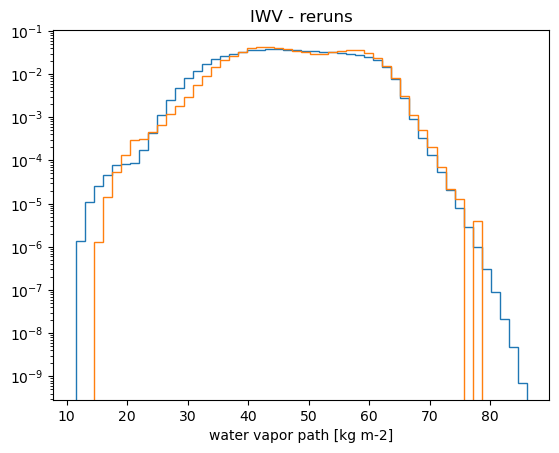

In [5]:
# Alldays:
hist_allcells_iwv=ds['prw'].plot.hist(bins=50,density=True, histtype='step') 
plt.yscale("log")
plt.title('IWV - alldays')
# Reruns:
hist_rerun_iwv=ds_icon_2d['prw'].plot.hist(bins=hist_allcells_iwv[1],density=True, histtype='step') 
#time steps 33 -> too big! maybe choose smaller?
plt.yscale("log")
plt.title('IWV - reruns')

plt.show()

In [19]:

#da_bins= 
array_all=np.concatenate((np.array(hist_allcells_iwv[0]),np.array([0])))
array_sub=np.concatenate((np.array(hist_rerun_iwv[0]),np.array([0])))
d= {"bins":hist_allcells_iwv[1] ,"all_data":array_all, "sub_selection":array_sub}
df_hist_iwv=pd.DataFrame(data=d)
#    h= ds[v].plot.hist(bins=bins_all["bins_"+v])
#    ds_bins_alldays[v][:-1]=h[0]

#df_hist_iwv.to_csv("hyd_climatology_hist_highest_res_1h_IWV.csv")

In [21]:
df_hist_iwv=pd.read_csv("hyd_climatology_hist_highest_res_1h_IWV.csv")

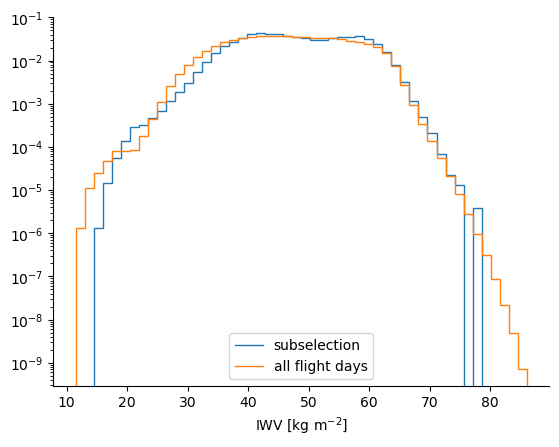

In [31]:

fig,ax=plt.subplots()
ax.stairs(df_hist_iwv["sub_selection"][:-1],df_hist_iwv["bins"],label='subselection')
ax.stairs(df_hist_iwv["all_data"][:-1],df_hist_iwv["bins"],label='all flight days')
plt.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('IWV [kg m$^{-2}$]')
plt.yscale("log")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 400

### LWP - alldays vs reruns

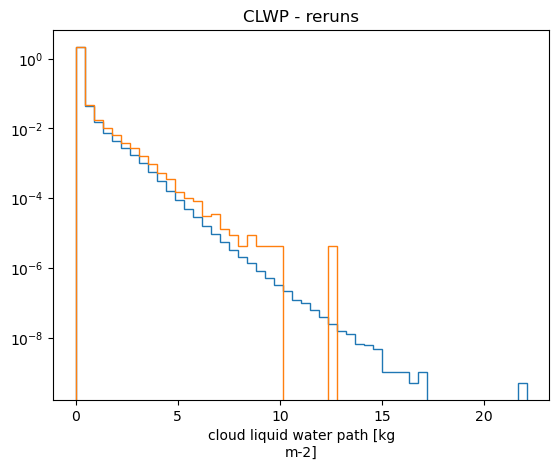

In [30]:
# this is with aaaall data 26.457924
da_lwp=ds['cllvi']#.values[:1000]#+ds_alldays['qrvi']
hist_allcells_lwp=da_lwp.plot.hist(bins=50,density=True, histtype='step') #plt.hist(da_lwp, bins=np.linspace(0,26.457924,51),density=True, histtype='step')#
plt.yscale("log")
plt.title('LWP - alldays')
#reruns
#da_lwp=ds_icon_2d['cllvi']#+ds_icon_2d['qrvi']
hist_rerun_lwp=plt.hist(CLWP,bins=hist_allcells_lwp[1],density=True, histtype='step') 
#time steps 33 -> too big! maybe choose smaller?
plt.yscale("log")
plt.title('CLWP - reruns')
plt.show()

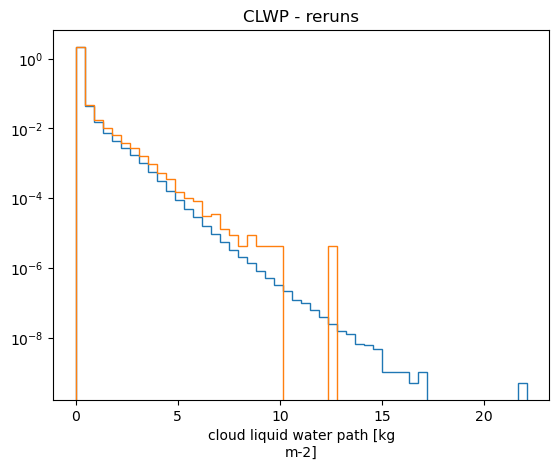

In [19]:
# this is with aaaall data 26.457924
da_lwp=ds['cllvi']#.values[:1000]#+ds_alldays['qrvi']
hist_allcells_lwp=da_lwp.plot.hist(bins=50,density=True, histtype='step') #plt.hist(da_lwp, bins=np.linspace(0,26.457924,51),density=True, histtype='step')#
plt.yscale("log")
plt.title('LWP - alldays')
#reruns
#da_lwp=ds_icon_2d['cllvi']#+ds_icon_2d['qrvi']
hist_rerun_lwp=plt.hist(CLWP,bins=hist_allcells_lwp[1],density=True, histtype='step') 
#time steps 33 -> too big! maybe choose smaller?
plt.yscale("log")
plt.title('CLWP - reruns')
plt.show()

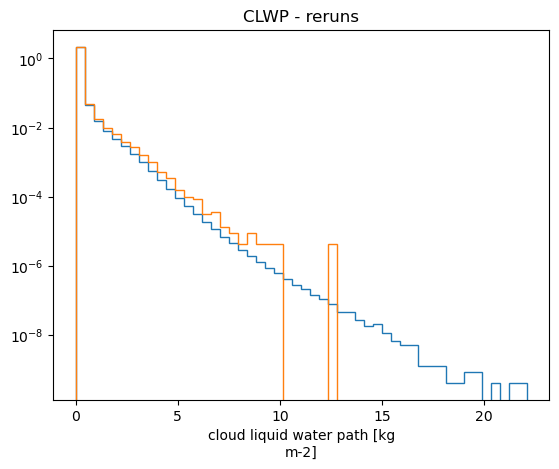

In [13]:
# this is with aaaall data 26.457924
da_lwp=ds['cllvi']#.values[:1000]#+ds_alldays['qrvi']
hist_allcells_lwp=da_lwp.plot.hist(bins=50,density=True, histtype='step') #plt.hist(da_lwp, bins=np.linspace(0,26.457924,51),density=True, histtype='step')#
plt.yscale("log")
plt.title('LWP - alldays')
#reruns
#da_lwp=ds_icon_2d['cllvi']#+ds_icon_2d['qrvi']
hist_rerun_lwp=plt.hist(CLWP,bins=hist_allcells_lwp[1],density=True, histtype='step') 
#time steps 33 -> too big! maybe choose smaller?
plt.yscale("log")
plt.title('CLWP - reruns')
plt.show()

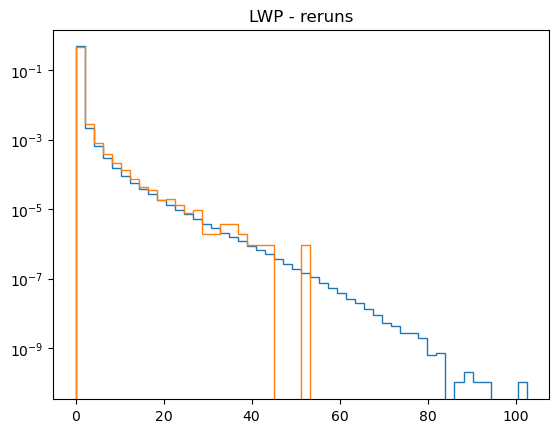

In [32]:
#alldays
da_lwp=ds['cllvi']+ds['qrvi']
hist_allcells_lwp=da_lwp.plot.hist(bins=50,density=True, histtype='step') 
plt.yscale("log")
plt.title('LWP - alldays')
#reruns
da_lwp=ds_icon_2d['cllvi']+ds_icon_2d['qrvi']
hist_rerun_lwp=da_lwp.plot.hist(bins=hist_allcells_lwp[1],density=True, histtype='step') 
#time steps 33 -> too big! maybe choose smaller?
plt.yscale("log")
plt.title('LWP - reruns')
plt.show()

In [31]:

array_all=np.concatenate((np.array(hist_allcells_lwp[0]),np.array([0])))
array_sub=np.concatenate((np.array(hist_rerun_lwp[0]),np.array([0])))
d= {"bins":hist_allcells_lwp[1] ,"all_data":array_all, "sub_selection":array_sub}
df_hist_lwp=pd.DataFrame(data=d)

#df_hist_lwp.to_csv("hyd_climatology_hist_highest_res_1h_CLWP.csv")

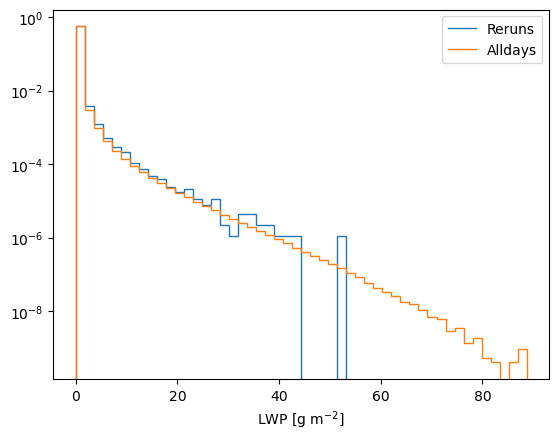

In [21]:
plt.stairs(hist_rerun_lwp[0],hist_rerun_lwp[1],label='Reruns')
plt.stairs(hist_allcells_lwp[0],hist_allcells_lwp[1],label='Alldays')
plt.legend()
plt.xlabel('LWP [kg m$^{-2}$]')
plt.yscale("log")

### IWP - alldays vs reruns

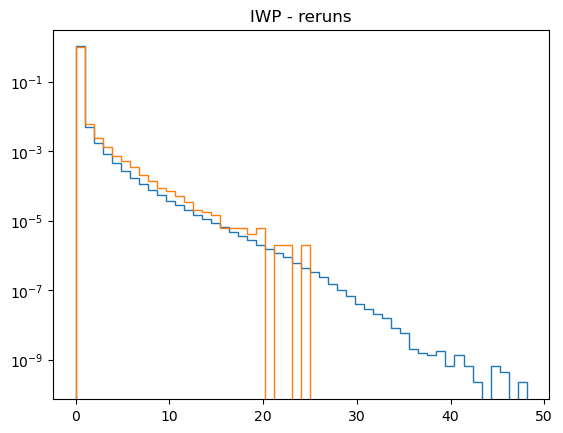

In [34]:
# 'qivi', #cloud ice path    'qsvi', #snow path    'qgvi' #graupel path
#alldays
da_iwp=ds['qivi']+ds['qsvi']+ds['qgvi']
da_iwp=da_iwp.compute()
hist_allcells_iwp=da_iwp.plot.hist(bins=50,density=True, histtype='step') 
da_iwp.close()
plt.yscale("log")
plt.title('IWP - alldays')
#reruns
da_iwp=ds_icon_2d['qivi']+ds_icon_2d['qsvi']+ds_icon_2d['qgvi']
da_iwp=da_iwp.compute()
hist_rerun_iwp=da_iwp.plot.hist(bins=hist_allcells_iwp[1],density=True, histtype='step') 
#time steps 33 -> too big! maybe choose smaller?
plt.yscale("log")
plt.title('IWP - reruns')
plt.show()

In [35]:
array_all=np.concatenate((np.array(hist_allcells_iwp[0]),np.array([0])))
array_sub=np.concatenate((np.array(hist_rerun_iwp[0]),np.array([0])))
d= {"bins":hist_allcells_iwp[1] ,"all_data":array_all, "sub_selection":array_sub}
df_hist_iwp=pd.DataFrame(data=d)
#df_hist_iwp.to_csv("hyd_climatology_hist_highest_res_1h_IWP.csv")

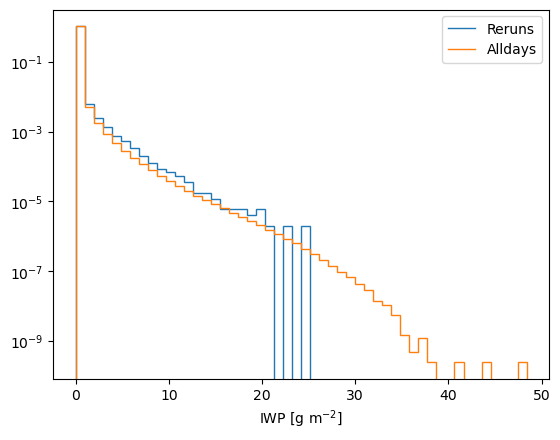

In [7]:
plt.stairs(hist_rerun_iwp[0],hist_rerun_iwp[1],label='Reruns')
plt.stairs(hist_allcells_iwp[0],hist_allcells_iwp[1],label='Alldays')
plt.legend()
plt.xlabel('IWP [kg m$^{-2}$]')
plt.yscale("log")

In [42]:
df_hist_lwp

,Unnamed: 0,bins,all_data,sub_selection
0,0,0.000000,2.184934e+00,2.171624
1,1,441.784859,4.460425e-02,0.047604
2,2,883.569717,1.526799e-02,0.017381
3,3,1325.354576,7.583211e-03,0.009953
4,4,1767.139435,4.432835e-03,0.006307
5,5,2208.924294,2.754994e-03,0.003901
6,6,2650.709152,1.715055e-03,0.002814
7,7,3092.494011,1.011742e-03,0.001639
8,8,3534.278870,5.623121e-04,0.000982
9,9,3976.063728,3.055576e-04,0.000535


## Plot all in one plot

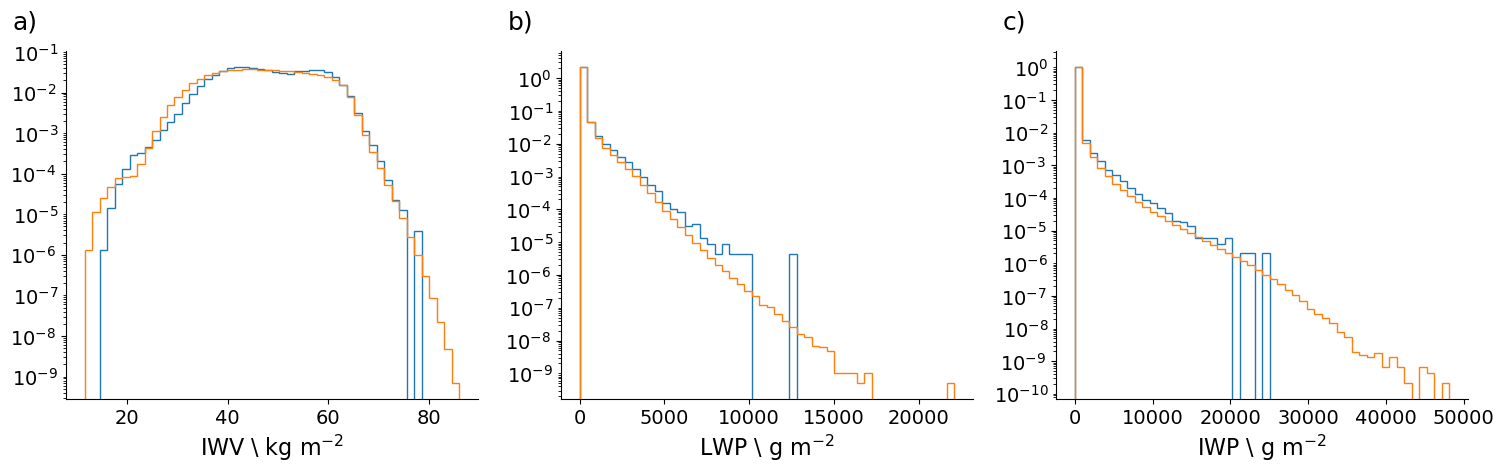

In [51]:
df_hist_iwv=pd.read_csv("hyd_climatology_hist_highest_res_1h_IWV.csv")
df_hist_lwp=pd.read_csv("hyd_climatology_hist_highest_res_1h_CLWP.csv")
df_hist_iwp=pd.read_csv("hyd_climatology_hist_highest_res_1h_IWP.csv")
df_hist_lwp['bins']=df_hist_lwp['bins']*1000
df_hist_iwp['bins']=df_hist_iwp['bins']*1000
dataframes = [
    (df_hist_iwv, 'IWV \\ kg m$^{-2}$', 'a)'),
    (df_hist_lwp, 'LWP \\ g m$^{-2}$', 'b)'),
    (df_hist_iwp, 'IWP \\ g m$^{-2}$', 'c)')
]
plt.rcParams.update({'font.size': 14}) # labels in 16
plt.rcParams['savefig.dpi'] = 400
# Create figure with 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 # subfigs = fig.subfigures(1, 3)
  #  subfig.text(0.0, 1.0, title, #transform=ax.transAxes,
   #                            fontsize='large',  va='top')
# Loop over each DataFrame and corresponding axis
for ax, (df, label, title) in zip(axes, dataframes):
    ax.stairs(df["sub_selection"][:-1], df["bins"])
    ax.stairs(df["all_data"][:-1], df["bins"])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlabel(label, fontsize=16)
    #ax.set_title(title)
    #ax.text(-0.1, 1.15, title, transform=ax.transAxes,
    #  fontsize=16, fontweight='bold', va='top', ha='right')
    ax.text(-0.13, 1.12, title,fontsize=18, transform=ax.transAxes,
        va='top')
    ax.set_yscale("log")
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12))
# Improve layout and display
plt.tight_layout()
filename= "hist_representativeness_all_CWLP"
plt.savefig(f'/home/u/u301032/orcestra/plots/{filename}.png')
plt.show()


### Überprüfen Condensate loads der aktuellen pamrtra simulationen. Dafür Anwendung des pamtra selektionsalgorithmus auf 2D file.

In [29]:
DATE= "0829" #"0927" #"0824" #
#NAME UNDER WHICH TO SAFE RUNS
output_name = "all_area_v1"
#Extend of Simulation area:
s_lat = -2
w_lon = -62
e_lon= -16
n_lat=22
flight_levels =[11400.0,11900.0,12650.0,13000.0,13250.0,13600.0,13900.0,14450.0,13900.0,15000.0	]
division_factor =1000 #1000 leads to ~ 6000 n_spatial

if DATE == "0829":
    appendix = "-high3Drate"
else:
    appendix = "-rerun"

path_sim = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/"
path = path_sim + f"orcestra_1250m_{DATE+appendix}/"
height_file = path_sim + f"orcestra_1250m_0829-high3Drate/orcestra_1250m_0829-high3Drate_atm_vgrid_ml.nc"

meshdir = "/work/mh0492/m301067/orcestra/auxiliary-files/grids/"
meshname = "ORCESTRA_1250m_DOM01"
frac_land_file= path + "bc_land_frac.nc"

twodim_file = path + f"orcestra_1250m_{DATE+appendix}_atm_2d_ml_DOM01_2024{DATE}T000000Z.nc"

#%%
# reading files
grid = xr.open_dataset(meshdir+meshname+".nc")


frac_land= xr.open_dataset(frac_land_file)
#sst = xr.open_dataset(SST_file) #TODO isel timestamp?? zeit falsch angegeben und nur 12 h schritte
twodim = xr.open_dataset(twodim_file)

#print(hyd,thermodyn)
#print(grid)


# %%%
#timestamps for DATE == "0824"
# selection of time stamps: 00,04,08,12,16,20, 24, 28, 32, 36 h
# selection of time = 36:00h

#Für Colocation : von 8 bis 20:00h
day = DATE[2:5]
month = DATE[0:2]
if DATE == "0829":
    t_periods = 4
else:
    t_periods = 5 #from 10
t_steps =xr.date_range("2024-"+month+"-"+day+" 12:00:00",periods=t_periods,freq="4h")


twodim = twodim.sel(time=t_steps)


#%% Index, spatial, TODO: Auslagern? da auch von pamtra comparison genutzt

lat = np.rad2deg(grid.clat.to_pandas()[frac_land.sea.to_pandas()==1])

lon=np.rad2deg(grid.clon.to_pandas()[frac_land.sea.to_pandas()==1])

try:    
    n_lat
    s_lat,
    e_lon,
    w_lon
except:
    print("no complete definiton of lon and lat area")    
else:
    lat=lat[(lat <= n_lat )&(lat >= s_lat)]
    lon=lon[(lon <= e_lon)&(lon >= w_lon)]
lon=lon[(lon <= e_lon)]
common_idx=lon.index.intersection(lat.index)
idx_list=common_idx.to_list()
#Reducing data size by factor 1000
common_idx=idx_list[0::division_factor]

SAMPLESIZE= len(common_idx) #n_spatial

print(SAMPLESIZE)


#for only one timestep

twodim = twodim.sel(ncells=common_idx)

6139


In [50]:
#["0829" ,"0927" ,"0824" ]
    #DATE= "0824" #"0829" #"0927" #"0824" #
    #twodim_0829=twodim
def load_twodim_old_pamtra(DATE):    
    if DATE == "0829":
        appendix = "-high3Drate"
    else:
        appendix = "-rerun"
    path = path_sim + f"orcestra_1250m_{DATE+appendix}/"
    
    twodim_file = path + f"orcestra_1250m_{DATE+appendix}_atm_2d_ml_DOM01_2024{DATE}T000000Z.nc"
    
    twodim= xr.open_dataset(twodim_file)
    day = DATE[2:5]
    month = DATE[0:2]
    if DATE == "0829":
        t_periods = 4
    else:
        t_periods = 5 #from 10
    t_steps =xr.date_range("2024-"+month+"-"+day+" 12:00:00",periods=t_periods,freq="4h")
    
    
    twodim = twodim.sel(time=t_steps)
    return twodim.sel(ncells=common_idx)
#twodim_0824
twodim_0829=load_twodim_old_pamtra("0829")
#twodim_0829
#twodim_0927=twodim_0927[variables].chunk()
twodim_0829    
twodim_0824=load_twodim_old_pamtra("0824")
twodim_0927=load_twodim_old_pamtra("0927")

In [39]:
bins_all= pd.read_csv("hyd_climatology_n.csv")
variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
# the xarrayyyy
ds_bins_alldays = xr.Dataset()
#xarray Grundgerüst erstellen  
for variable in variables:
    bin_values = bins_all["bins_"+variable] # unterschiedlich für jede Größe
    time_values=pd.date_range(start='2024-08-10', end='2024-09-30')
    array =  np.zeros((len(time_values),len(bin_values))) #n2 # shape: time,bins
    da=xr.DataArray(array, dims=("time","bins_"+variable), coords={"bins_"+variable: bin_values, "time": time_values})
    ds_bins_alldays[variable]=da
  

<xarray.Dataset> Size: 4MB
Dimensions:   (time: 5, height: 1, height_2: 1, ncells: 6139)
Coordinates:
  * time      (time) datetime64[ns] 40B 2024-08-24T12:00:00 ... 2024-08-25T04...
  * height    (height) float64 8B 2.0
  * height_2  (height_2) float64 8B 10.0
Dimensions without coordinates: ncells
Data variables: (12/32)
    psl       (time, ncells) float32 123kB ...
    ts        (time, ncells) float32 123kB ...
    clt       (time, ncells) float32 123kB ...
    pr        (time, ncells) float32 123kB ...
    prw       (time, ncells) float32 123kB ...
    cllvi     (time, ncells) float32 123kB ...
    ...        ...
    qgvi      (time, ncells) float32 123kB ...
    qrvi      (time, ncells) float32 123kB ...
    qsvi      (time, ncells) float32 123kB ...
    uas       (time, height_2, ncells) float32 123kB ...
    vas       (time, height_2, ncells) float32 123kB ...
    hus2m     (time, height, ncells) float32 123kB ...
Attributes:
    CDI:                  Climate Data Interface version 2.4.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  42
    uuidOfHGrid:          d91eb16c-5cb5-11ef-bad0-d926b45399a4
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               https://gitlab.dkrz.de/icon/icon-mpim.git@1fa5838fd...
    history:              /work/mh0492/m301067/orcestra/icon-mpim/build-lamor...
    references:           see MPIM/DWD publications
    comment:              Romain Fievet (m301067) on l30295 (Linux 4.18.0-513...

# Histograms of old pamtra reruns

In [52]:
variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
twodim_0824=twodim_0824[variables].chunk()
#twodim_0824
twodim_0829=twodim_0829.chunk()
#twodim_0829
twodim_0927=twodim_0927[variables].chunk()
#twodim_0927
ds=xr.concat([twodim_0824,twodim_0829,twodim_0927],dim='time')
ds=ds[variables]
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 14, ncells: 6139)
Coordinates:
  * time     (time) datetime64[ns] 112B 2024-08-24T12:00:00 ... 2024-09-28T04...
Dimensions without coordinates: ncells
Data variables:
    prw      (time, ncells) float32 344kB dask.array<chunksize=(5, 6139), meta=np.ndarray>
    qivi     (time, ncells) float32 344kB dask.array<chunksize=(5, 6139), meta=np.ndarray>
    cllvi    (time, ncells) float32 344kB dask.array<chunksize=(5, 6139), meta=np.ndarray>
    qrvi     (time, ncells) float32 344kB dask.array<chunksize=(5, 6139), meta=np.ndarray>
    qsvi     (time, ncells) float32 344kB dask.array<chunksize=(5, 6139), meta=np.ndarray>
    qgvi     (time, ncells) float32 344kB dask.array<chunksize=(5, 6139), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 2.4.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  42
    uuidOfHGrid:          d91eb16c-5cb5-11ef-bad0-d926b45399a4
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               https://gitlab.dkrz.de/icon/icon-mpim.git@1fa5838fd...
    history:              /work/mh0492/m301067/orcestra/icon-mpim/build-lamor...
    references:           see MPIM/DWD publications
    comment:              Romain Fievet (m301067) on l30295 (Linux 4.18.0-513...

variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
ds=xr.concat([twodim_0824[variables],twodim_0829[variables],twodim_0927[variables]],dim='time')

In [56]:
ds.time.values



array(['2024-08-24T12:00:00.000000000', '2024-08-24T16:00:00.000000000',
       '2024-08-24T20:00:00.000000000', '2024-08-25T00:00:00.000000000',
       '2024-08-25T04:00:00.000000000', '2024-08-29T12:00:00.000000000',
       '2024-08-29T16:00:00.000000000', '2024-08-29T20:00:00.000000000',
       '2024-08-30T00:00:00.000000000', '2024-09-27T12:00:00.000000000',
       '2024-09-27T16:00:00.000000000', '2024-09-27T20:00:00.000000000',
       '2024-09-28T00:00:00.000000000', '2024-09-28T04:00:00.000000000'],
      dtype='datetime64[ns]')

In [ ]:
#Hist of current pamtra runs
bins_all= pd.read_csv("hyd_climatology_n.csv")
variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
# the xarrayyyy
ds_bins_alldays = xr.Dataset()
#xarray Grundgerüst erstellen  
for variable in variables:
    bin_values = bins_all["bins_"+variable] # unterschiedlich für jede Größe
    #time_values=pd.DatetimeIndex(data=["2024-08-24"])#,"2024-08-29","2024-09-27"])#pd.date_range(start='2024-08-10', end='2024-09-30')
    array =  np.zeros((len(bin_values))) #n2 # shape: time,bins
    da=xr.DataArray(array, dims=("bins_"+variable), coords={"bins_"+variable: bin_values})
    ds_bins_alldays[variable]=da
  
for v in variables:
#    label="2024-08-24"
    #ds[v]=ds_alldays[v].groupby_bins(bins=bins_all["bins_"+v])#.resample(time='1D').map(digi,var=v)
    #ds[v]=ds_alldays[v].resample(time='1D').map(xr.plot.hist(ds,bins=bins_all["bins_"+v]))
    #a=ds_alldays[v].resample(time='1D').map(hist,var=v)
    #ds[v]=ds_alldays[v].resample(time='1D').map(hist,var=v)
    h= ds[v].plot.hist(bins=bins_all["bins_"+v])
    ds_bins_alldays[v][:-1]=h[0]
    #for label, group in ds[v].resample(time='1D'):
    #    h=group.plot.hist(bins=bins_all["bins_"+v])
    #    ds_bins_alldays[v].loc[label][:-1]=h[0]
    ds_bins_alldays.to_netcdf("hyd_climatology_pamtra_4h_factor1000.nc")

ds_bins_alldays


In [ ]:
ds_alldays[variables].sel(time=[slice("2024-08-24","2024-08-25"),"2024-08-29","2024-09-27"])# testen ob funktioniert
#Wenn ja, dann:
hist_reruns=[]
for day in ["2024-08-24","2024-08-29","2024-09-27"]:

  a=ds_alldays[variables].sel(time=slice(day,pd.Timestamp(day)+pd.Timedelta(23,"h")))
  print(day)
  hist_rerun=[a[variable].plot.hist(bins=100) for variable in variables]
  hist_reruns.append(hist_rerun)
hist_reruns_np=np.array(hist_reruns,dtype=object)
#df=pd.DataFrame(data={'n1':hist_reruns[],'bins':,'time':["2024-08-24","2024-08-29","2024-09-27"]})
#
#foo = xr.DataArray(np.array(hist_reruns,dtype=object), coords=times, dims=["time","variables","unit"])
#xr.Dataset(
#  {
#    "n": (["time","variable"],np.array(hist_reruns,dtype=object)[:,:,0]),
#    "bins": (["time","variable"],np.array(hist_reruns,dtype=object)[:,:,1])
#  },
#  coords={
#        "variable": variables,
#        "time": times,
#    },
#)
times=["2024-08-24","2024-08-29","2024-09-27"]
for i in range(6):
  #n1=hist_reruns[3*2*i]
  #bins1=hist_reruns[2*i+1]
  
  n2= hist[2*i]
  bins2=hist[2*i+1]
  plt.stairs(n2[1:], bins2[1:],fill=True)
  plt.stairs(hist_reruns_np[0,i,0][1:],hist_reruns_np[0,i,1][1:])
  for day in range(3):
    plt.stairs(hist_reruns_np[day,i,0][1:],hist_reruns_np[day,i,1][1:],label=times[day])#, baseline=hist_reruns_np[day,i,0])
    
  plt.legend()
  plt.yscale("log")
  plt.title(variables[i])
  plt.show()
  print(variables[i],2*i)
  

  #
hist_reruns=[ds_alldays[variable].sel(time=["2024-08-24","2024-08-29","2024-09-27"]).plot.hist(bins=100) for variable in variables]
for i in range(6):
  n2= hist[2*i]
  bins2=hist[2*i+1]
  plt.stairs(n2[1:], bins2[1:],fill=True)
  #plt.legend()
  plt.yscale("log")
  plt.title(variables[i])
  plt.show()
  print(variables[i],2*i)
#plot histogram of condensate loads for all days together
# Condensate loads of interest: IWV, IWP, PP
# -> 3 plots
#bins = np.arange(50,15060,100)
#(n2, bins2, patches) = plt.hist(ds_alldays.prw,bins=100)
#plt.stairs(n2, bins2,fill=False)

# names of variables
# prw water vapor path
# qivi cloud ice path
# cllvi cloud liquid water path
# qrvi rain path
# qsvi snow path
# qgvi graupel path



# plot histogram of the 3 rerun days combined
# -> 3 plots
# merge upper 6 plots into 3 plots
# check, if upper and lower ends of rerun days extent to same variability as all days combined
# if not, think about how to choose which days to take extra in account
# if yes, check if subsampled area (100th icon) has same variability

#print(fs.glob("ipns://latest.orcestra-campaign.org/products/HALO/iwv/*.zarr"))


In [ ]:
'''
Comparing pamtra simulation and halo data
plus choosing of flight levels
'''


#%% Loading packages
import numpy as np

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import fsspec
from matplotlib import cm
from matplotlib.colors import Normalize 
from scipy.interpolate import interpn
import glob
from functools import partial
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/')
#import src
import src_comparison_halo_pamtra as chp

#%% Data Comparison condensate loads all campaign days with reruns (2D field)
#Read in all 2D fields.
'''
Comparing pamtra simulation and halo data
plus choosing of flight levels
'''

#ds_remap.coarsen(lat=1,lon=1,boundary='pad').construct({"lat":("lat_c",lat), "lon":("lon_c",lon)})





#%% Data Comparison condensate loads all campaign days with reruns (2D field)
#Read in all 2D fields.
DATE="0829"
appendix = ""

path_sim = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/"
path = path_sim + f"orcestra_1250m_{DATE+appendix}/"
twodim_file = path + f"orcestra_1250m_{DATE+appendix}_atm_2d_ml_DOM01_2024{DATE}T000000Z.nc"
twodim_files  = path_sim + "orcestra_1250m_*[0-9]/" +"orcestra_1250m_*_atm_2d_ml_DOM01_2024*T000000Z.nc"

# Opening Multifile Dataset
# Limiting simulation data from 24h - 48 h
def _preprocess(x, start_time="24h"):#, end_time="48h" ):
  # selecting variables of interest
  variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
  x=x[variables]

  # selecting time
  start=x.time[0].values+pd.Timedelta(start_time)
  #stop=x.time[0].values +pd.Timedelta(end_time) #last time step
  stop=x.time[-2].values #last time step
  t_steps =xr.date_range(start,stop,freq="2h")
  #print(start)
  return x.sel(time=t_steps)


#ds_alldays=xr.concat([xr.open_dataset(i,preprocess=partial_func,engine ="zarr")for i in twodim_files],dim="time")

#twodim_files_list =glob.glob(twodim_files)
#ds_alldays=xr.concat([_preprocess(xr.open_dataset(i))for i in twodim_files_list],dim="time")


def read_grid_and_cell_data():
  meshdir = "/work/mh0492/m301067/orcestra/auxiliary-files/grids/"
  meshname = "ORCESTRA_1250m_DOM01"
  DATE="0829"
  appendix = ""
  path_sim = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/"
  path = path_sim + f"orcestra_1250m_{DATE+appendix}/"
  frac_land_file= path + "bc_land_frac.nc"
  grid = xr.open_dataset(meshdir+meshname+".nc",chunks="auto")
  frac_land= xr.open_dataset(frac_land_file, chunks={"cell": -1})
  frac_land=frac_land.drop_dims("nv")
  return grid,frac_land





division_factor =1000 #1000 leads to ~ 6000 n_spatial

#Reading and First Processing of datasets
partial_func = partial(_preprocess,start_time="24h") #, end_time="48h")
#ds= _preprocess(xr.open_dataset(twodim_file, chunks={"ncells": -1}))
ds_alldays= xr.open_mfdataset(twodim_files,preprocess=partial_func, chunks={"ncells": -1})#,chunks="auto", parallel=True)
grid,frac_land = read_grid_and_cell_data()


if "cell" in set(frac_land.dims): 
    frac_land=chp.remap(frac_land,input_core_dim="cell")
frac_land=chp.cut_to_area(frac_land)

ds_remap=chp.remap(ds_alldays)
ds_remap=chp.cut_to_area(ds_remap)


ds_sea=ds_remap.where(frac_land.sea==1) 
ds_small=chp.coarse_for_pamtra(ds_sea,res=0.5)
ds_small.isel(time=0).plot.scatter(x="lat",y="lon",marker='.')
plt.show()
#Max:
#prw 100 #wahrscheinlich zu hoch. sonst 80?
# qivi: 3.619194
#cllvi 21.685883
#qrvi 88.09291
#qgvi 47.29776
#qsvi 17.277763
#bins = np.linspace(0,3.62,num=100)
#(n2, bins2, patches) = plt.hist(ds_alldays.qivi, bins)

variables = [
    'prw', #water vapor path
    'qivi', #cloud ice path
    'cllvi', #cloud liquid water path
    'qrvi', #rain path
    'qsvi', #snow path
    'qgvi' #graupel path
  ]
si_units = []
#hist=[ds_alldays[variable].plot.hist(bins=100) for variable in variables]
#print(hist)


#################################################################################################################
# %%
# Setup environment

#%matplotlib inline

from pylab import *

import netCDF4 as nc
import xarray as xr
import numpy as np
import cartopy.feature as cf
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
#import matplotlib.font_managerquit()

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import itertools
import os
import dask
import easygems.remap as egr
import datashader as ds
#import psutil
import seaborn
import matplotlib.colors as mcolors

from matplotlib import gridspec
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import gaussian_filter

#os.environ['TEXMFHOME'] = '/home/m/m301067/texmf'
#os.environ['PATH'] = '/sw/spack-levante/texlive-live2021-l5o6sw/bin/x86_64-linux:' + os.environ['PATH']
#plt.rcParams.update({'font.size': 13, 'font.family': 'TimesNewRoman', 'text.usetex': True})
#rcParams['axes.linewidth'] = 1.5
#rcParams["axes.formatter.use_mathtext"]
    
# Customize the tick labels to remove the minus sign (its in °W)
def format_longitude(x, pos):
    return f"{abs(int(x))}"

# %%
def remap(ds,ires=3,input_core_dim="ncells"):
    """
    Uses the weights given by sim for remapping
    :param str input_core_dim: for frac land use "cell"
    :param int ires: resolution of remapping. can be a value of 1, 2 or 3. 3 has highest resolution: 1 #1:HD, 2:2K, 3:4k(~1.25km resolution)
    """

    # Update the figure's size according to target resolution
    nx, ny = 1440 * ires, 720 * ires
    dpi = 150*ires
    plt.rcParams['figure.dpi'] = 150*ires #450: 4K, 300: 2K, 150: HD to stay coherent


    # Reading the dataset

    #datadir = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/orcestra_1250m_"+mmdd+"/"
    weightsdir = "/work/mh0492/m301067/orcestra/auxiliary-files/weights/"
    #datafile = "orcestra_1250m_"+mmdd+"_atm_2d_ml_DOM01_2024"+mmdd+ "T000000Z.nc"
    meshdir = "/work/mh0492/m301067/orcestra/auxiliary-files/grids/"
    meshname = "ORCESTRA_1250m_DOM01"

    #ds = xr.open_dataset(datadir+datafile, chunks={"ncells": -1})
    grid = xr.open_dataset(meshdir+meshname+".nc")

    lon, lat = np.meshgrid(
        np.linspace(grid.clon.min().values, grid.clon.max().values, nx), 
        np.linspace(grid.clat.min().values, grid.clat.max().values, ny)
    )

    # Compute (load) remapping weightsm
    weightsname = "weights_"+meshname+"_ZoomLvl"+str(ires)
    if os.path.exists(weightsdir+weightsname+".nc"):
        print("Reading weights")
        weights = xr.open_dataset(weightsdir+weightsname+".nc")
    else:
        print("Calculating weights")
        weights = egr.compute_weights_delaunay((grid.clon, grid.clat), (lon.ravel(), lat.ravel()))
        weights.to_netcdf(weightsdir+weightsname+".nc", mode="w")

    # Apply remapping function only to the variables we need
    ds_remap = xr.apply_ufunc(
        egr.apply_weights,
        ds,
        kwargs=weights,
        input_core_dims=[[input_core_dim]],
        output_core_dims=[["xy"]],
        output_dtypes=["f4"],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={
            "output_sizes": {"xy": lon.size},
        },
    )

    # Assign the MultiIndex to the 'xy' dimension
    ds_remap = ds_remap.assign_coords(
        xy=pd.MultiIndex.from_product(
            (np.degrees(lat[:, 0]), np.degrees(lon[0, :])), 
            names=("lat", "lon"),
        )
    ).unstack("xy")


    return ds_remap

def plotting_R(ds,time2plot):
        # Extract and format the time dimension
    times = ds.time.values
    num_snapshots = len(times)
    print(f"Number of snapshots: {num_snapshots}, among which we plot number {time2plot}")
    formatted_times = [pd.to_datetime(str(time)).strftime('%Y-%m-%dT%H-%M') for time in times]
    formatted_time = formatted_times[time2plot]
    return num_snapshots, formatted_time


def read_grid_and_cell_data():
  meshdir = "/work/mh0492/m301067/orcestra/auxiliary-files/grids/"
  meshname = "ORCESTRA_1250m_DOM01"
  DATE="0829"
  appendix = ""
  path_sim = "/work/mh0492/m301067/orcestra/icon-mpim/build-lamorcestra/experiments/"
  path = path_sim + f"orcestra_1250m_{DATE+appendix}/"
  frac_land_file= path + "bc_land_frac.nc"
  grid = xr.open_dataset(meshdir+meshname+".nc",chunks="auto")
  frac_land= xr.open_dataset(frac_land_file,chunks="auto")
  return grid,frac_land

def cut_data_to_area_of_interest(ds,s_lat = -2,w_lon = -62,e_lon= -16,n_lat=22,division_factor=1000): #Koordinaten eigentlich in Dictionary
  # probably outdated
  #lonlat Grenzen übernehmen
  grid,frac_land = read_grid_and_cell_data()
  lat = np.rad2deg(grid.clat.to_pandas()[frac_land.sea.to_pandas()==1])
  lon=np.rad2deg(grid.clon.to_pandas()[frac_land.sea.to_pandas()==1])
  lat=lat[(lat <= n_lat )&(lat >= s_lat)]
  lon=lon[(lon <= e_lon)&(lon >= w_lon)]
  common_idx=lon.index.intersection(lat.index)
  idx_list=common_idx.to_list()
  #Reducing data size by factor 1000
  common_idx=idx_list[0::division_factor]
  ds=ds.sel(ncells=common_idx)

  frac_land = frac_land.drop_dims("nv")
  frac_land = frac_land.sel(cell = common_idx)

  #oder über selection?
  #ds.sel()
  #TODO plot 1000. Icon selection, make sure index passt, und wird übergeben für Vergleich für gridded notwendig
  return ds,common_idx,lon,lat

def cut_to_area(ds,s_lat = -2,w_lon = -62,e_lon= -16,n_lat=22):
  """
  cuts area of dataset to smaller size  
  :param float res: resolution of longitude and latitude 
  """
  ds=ds.sel(lat=slice(s_lat,n_lat),lon=slice(w_lon,e_lon))
  
  return ds

def coarse_for_pamtra(ds,s_lat = -2,w_lon = -62,e_lon= -16,n_lat=22,res=1):
  """
  coarsens dataset (and cuts it to area)
  :param float res: resolution of longitude and latitude 
  """
  ds=cut_to_area(ds,s_lat,w_lon,e_lon,n_lat)

  lat_range=np.arange(s_lat,n_lat+0.49*res,res)
  lon_range=np.arange(w_lon,e_lon+0.49*res,res)  
  ds=ds.sel(lat=lat_range,lon=lon_range,method="nearest")
  return ds

## flight heights

In [4]:
#xr.open_dataset("ipfs://QmbhkFCwHtd9TQXYUsm1uzXzKov19JGbkHi5c8mRoHgzPp/products/HALO/position_attitude/HALO-20240923a.zarr", engine="zarr")
fs = fsspec.filesystem("ipns")
list_a=(fs.glob("ipns://latest.orcestra-campaign.org/products/HALO/position_attitude/*"))
#list_a=(fs.glob("ipfs://QmbhkFCwHtd9TQXYUsm1uzXzKov19JGbkHi5c8mRoHgzPp/products/HALO/position_attitude/*"))

NameError: name 'AsyncGateway' is not defined